In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['svg.fonttype'] = 'none'

base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/"

In [98]:
# Implement Benjamini-Hochberg FDR correction
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    n = pvals.shape[0]
    order = np.argsort(pvals)
    ranked_pvals = pvals[order]
    adjusted = np.empty(n, dtype=float)

    # Compute adjusted p-values
    cumulative_min = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        bh_value = ranked_pvals[i] * n / rank
        bh_value = min(bh_value, 1.0)
        cumulative_min = min(cumulative_min, bh_value)
        adjusted[i] = cumulative_min

    # Restore original order
    pvals_adjusted = np.empty(n, dtype=float)
    pvals_adjusted[order] = adjusted
    return pvals_adjusted


In [99]:
def run_mut_comparision_anova_and_plot(
    df, 
    dataset_name, 
    feature_name, 
    mutations, 
    mutation_factor_colname, 
    results, 
    do_plot=False,
    verbose=False,
    train=False,
    aggregate=True,
    save=True,
    fig_path=None,
    color_map=color_map,
    min_points_for_anova=5,
    min_groups_for_anova=3,
    comp_factor="model_name"
):
    feature = feature_name
    comparison_type = "train" if train else "test"

    def significance_code(pval):
        if pval is None:
            return "N.S."
        if pval > 0.05:
            return "N.S."
        elif 0.01 < pval <= 0.05:
            return "*"
        elif 0.001 < pval <= 0.01:
            return "**"
        elif pval <= 0.001:
            return "***"

    if do_plot:
        col_size = 1.5
        row_size = 1.5
        fig, axes = plt.subplots(
            1,
            len(mutations),
            figsize=(col_size * len(mutations), row_size),
            constrained_layout=True
        )
        title_fontsize = globals().get('title_fontsize', 9)
        label_fontsize = globals().get('label_fontsize', 8)
        tick_fontsize = globals().get('tick_fontsize', 7)
        legend_fontsize = globals().get('legend_fontsize', 7)
        if len(mutations) == 1:
            axes = [axes]

    ordered = list(color_map.keys())
    for idx, train_muts in enumerate(mutations):
        df_plot = df[df[mutation_factor_colname] == train_muts]
        # Order the model names according to "ordered" and only keep those present in df_plot
        present_groups_in_factor = set(df_plot[comp_factor].unique())
        ordered_group_names = [m for m in ordered if m in present_groups_in_factor]
        group_names = ordered_group_names  # Boxplot and coloring will use this order

        box_data = [df_plot[df_plot[comp_factor] == group][feature].dropna().values for group in group_names]

        # Default values for both tests
        f_stat, p_value = None, None
        k_stat, k_p_value = None, None
        test_type = None

        if len(box_data) > 1 and all(len(g) > 1 for g in box_data):
            print("ANOVA SIZE %d Groups, %d points in group for %s[%s] %d" % (len(box_data), len(box_data[0]), feature, mutation_factor_colname, train_muts))
            # ANOVA
            f_stat, p_value = stats.f_oneway(*box_data)
            # Kruskal-Wallis
            k_stat, k_p_value = stats.kruskal(*box_data)

            test_type = "ANOVA"

            if len(box_data[0]) < min_points_for_anova or len(box_data) < min_groups_for_anova:
                test_type = "permutation"
                print("Running permutation tests")

                k_obs = k_stat
                f_obs = f_stat

                f_all = []

                for i in range(10000):
                    permuted_data = np.random.permutation(np.array(box_data))
                    f_stat_perm, p_value_perm = stats.f_oneway(*permuted_data)
                    f_all.append(f_stat_perm)

                f_stat = f_obs
                k_stat = k_obs 
                p_value = 1 - np.sum(np.sort(np.array([f_all]) <= f_obs)) / len(f_all)
                k_p_value = np.nan
            if verbose:
                print(
                    f"### F = {f_stat:.3f}, p = {p_value:.3f} ({test_type}) | "
                    f"Kruskal-Wallis H = {k_stat:.3f}, p = {k_p_value:.3f}"
                )
        else:
            f_stat, p_value = None, None
            k_stat, k_p_value = None, None
            test_type = None

        if aggregate:
            results.setdefault("feature", []).append(feature)
            results.setdefault("comparison_type", []).append(comparison_type)
            results.setdefault("mutations", []).append(train_muts)
            results.setdefault("dataset", []).append(dataset_name)
            results.setdefault("test_type", []).append(test_type)
            results.setdefault("F_value", []).append(f_stat)
            results.setdefault("P_value", []).append(p_value)
            results.setdefault("Kruskal_H", []).append(k_stat)
            results.setdefault("Kruskal_P", []).append(k_p_value)
            

        if do_plot:
            ax = axes[idx]

            # Build facecolors for each box by model order
            box_colors = []
            for group in group_names:
                if group in color_map:
                    box_colors.append(color_map[group])
                else:
                    box_colors.append("#cccccc")

            # Draw boxes invisibly and color via Patch instead of modifying after
            bp = ax.boxplot(
                box_data,
                patch_artist=True,
                boxprops=dict(linewidth=1, color='black'),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(linewidth=1, color='black'),
                capprops=dict(linewidth=1, color='black'),
                flierprops=dict(markerfacecolor='black', marker="o", markersize=3.5, alpha=0.8, linestyle='none', markeredgecolor='none')
            )

            # Apply facecolor directly
            for patch, color in zip(bp['boxes'], box_colors):
                patch.set_facecolor(color)

            ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.set_xticks(range(1, len(group_names) + 1))
            ax.set_xticklabels("")
            ax.set_xlabel(xlabel_dict.get(comp_factor, 'Model Name'), fontsize=label_fontsize, labelpad=3)
            if comparison_type == "train":
                title_str = f'Mutations in {comparison_type}: {train_muts}\n'
            else:
                title_str = f'Held out test set: {train_muts}\n'

            # Calculate y-limits for safe sig label
            all_yvals = np.concatenate([np.asarray(d) for d in box_data if len(d) > 0])
            if len(all_yvals) > 0:
                max_y = np.max(all_yvals)
                min_y = np.min(all_yvals)
            else:
                max_y = 1.0
                min_y = 0.0
            y_span = max_y - min_y if max_y > min_y else 1.0

            sig_y = max_y + 0.08 * y_span

            sig_str = ""
            if f_stat is not None and p_value is not None:
                sig_str = significance_code(p_value)

            if sig_str:
                # Place sig code at the center x-position of the plot, right above the x label area
                mid_xtick = int(np.ceil(len(group_names) / 2))
                ax.text(
                    mid_xtick, sig_y,
                    "%s (%s)" % (sig_str, "perm." if test_type == "permutation" else test_type),
                    fontsize=8,
                    ha='center',
                    va='bottom',
                    color='black'
                )

            ax.set_title(title_str, fontsize=8, pad=5)
            ax.tick_params(axis='x', labelsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            if idx == 0:
                ax.set_ylabel(ylabel_dict.get(feature, feature), labelpad=6, fontsize=label_fontsize)
            else:
                ax.set_ylabel('')

            # Adjust y-limits for sig code to avoid overlap
            upper_margin = 0.15 * y_span
            lower_margin = 0.04 * y_span
            ax.set_ylim(min_y - lower_margin, max_y + upper_margin)

    if fig_path is not None:
        plt.savefig(fig_path, format='svg')
    if do_plot:
        plt.show()
    return results

In [104]:
anova_agg = {
    "feature": [],
    "comparison_type": [],
    "mutations": [],
    "dataset": [],
    "test_type": [],
    "F_value": [],
    "P_value": [],
    "Kruskal_H": [],
    "Kruskal_P": []
}


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV 

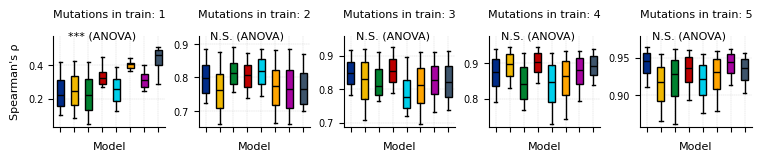

ANOVA SIZE 8 Groups, 2 points in group for correlation[test_mutations] 3
Running permutation tests
### F = 0.006, p = 0.045 (permutation) | Kruskal-Wallis H = 0.353, p = nan
ANOVA SIZE 8 Groups, 3 points in group for correlation[test_mutations] 4
Running permutation tests
### F = 0.012, p = 0.103 (permutation) | Kruskal-Wallis H = 0.307, p = nan
ANOVA SIZE 8 Groups, 4 points in group for correlation[test_mutations] 5
Running permutation tests
### F = 0.019, p = 0.760 (permutation) | Kruskal-Wallis H = 0.443, p = nan
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 6
### F = 0.024, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.378, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 7
### F = 0.031, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.500, p = 0.999
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 8
### F = 0.037, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.685, p = 0.998


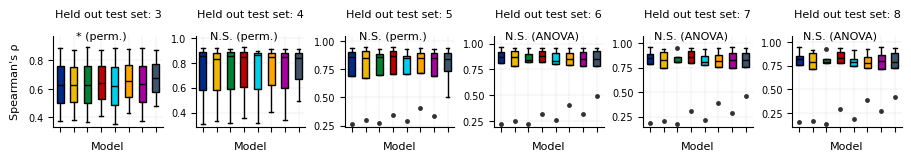


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.

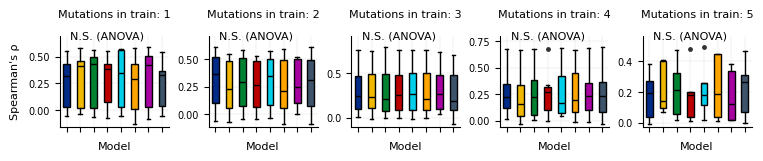

ANOVA SIZE 8 Groups, 2 points in group for correlation[test_mutations] 3
Running permutation tests
### F = 0.346, p = 0.259 (permutation) | Kruskal-Wallis H = 3.221, p = nan
ANOVA SIZE 8 Groups, 3 points in group for correlation[test_mutations] 4
Running permutation tests
### F = 0.055, p = 0.198 (permutation) | Kruskal-Wallis H = 1.147, p = nan
ANOVA SIZE 8 Groups, 4 points in group for correlation[test_mutations] 5
Running permutation tests
### F = 0.076, p = 0.006 (permutation) | Kruskal-Wallis H = 0.665, p = nan
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 6
### F = 1.072, p = 0.404 (ANOVA) | Kruskal-Wallis H = 6.483, p = 0.485
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 7
### F = 0.243, p = 0.971 (ANOVA) | Kruskal-Wallis H = 2.546, p = 0.924
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 8
### F = 0.495, p = 0.831 (ANOVA) | Kruskal-Wallis H = 3.480, p = 0.837


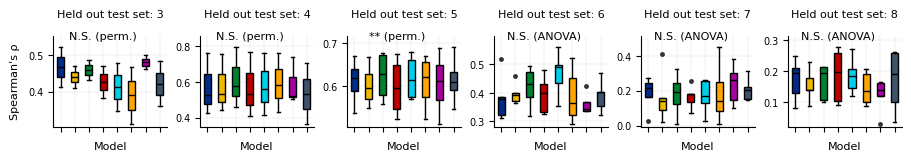


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2

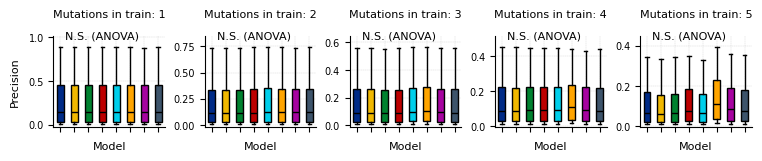

ANOVA SIZE 8 Groups, 2 points in group for precision[test_mutations] 3
Running permutation tests
### F = 0.004, p = 0.247 (permutation) | Kruskal-Wallis H = 1.291, p = nan
ANOVA SIZE 8 Groups, 3 points in group for precision[test_mutations] 4
Running permutation tests
### F = 0.005, p = 0.155 (permutation) | Kruskal-Wallis H = 0.687, p = nan
ANOVA SIZE 8 Groups, 4 points in group for precision[test_mutations] 5
Running permutation tests
### F = 0.004, p = 0.345 (permutation) | Kruskal-Wallis H = 0.242, p = nan
ANOVA SIZE 8 Groups, 5 points in group for precision[test_mutations] 6
### F = 0.022, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.403, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for precision[test_mutations] 7
### F = 0.119, p = 0.996 (ANOVA) | Kruskal-Wallis H = 0.487, p = 0.999
ANOVA SIZE 8 Groups, 5 points in group for precision[test_mutations] 8
### F = 0.261, p = 0.965 (ANOVA) | Kruskal-Wallis H = 0.714, p = 0.998


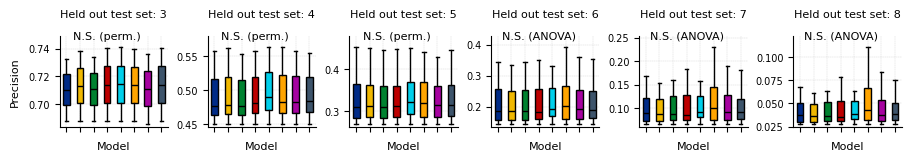

ANOVA SIZE 8 Groups, 9 points in group for recall[train_mutations] 1
### F = 0.344, p = 0.930 (ANOVA) | Kruskal-Wallis H = 4.235, p = 0.752
ANOVA SIZE 8 Groups, 8 points in group for recall[train_mutations] 2
### F = 1.842, p = 0.097 (ANOVA) | Kruskal-Wallis H = 16.471, p = 0.021
ANOVA SIZE 8 Groups, 7 points in group for recall[train_mutations] 3
### F = 0.399, p = 0.898 (ANOVA) | Kruskal-Wallis H = 5.723, p = 0.572
ANOVA SIZE 8 Groups, 6 points in group for recall[train_mutations] 4
### F = 0.167, p = 0.990 (ANOVA) | Kruskal-Wallis H = 1.440, p = 0.984
ANOVA SIZE 8 Groups, 5 points in group for recall[train_mutations] 5
### F = 0.490, p = 0.835 (ANOVA) | Kruskal-Wallis H = 4.358, p = 0.738


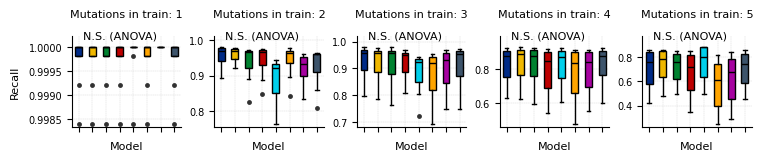

ANOVA SIZE 8 Groups, 2 points in group for recall[test_mutations] 3
Running permutation tests
### F = 0.058, p = 0.097 (permutation) | Kruskal-Wallis H = 0.408, p = nan
ANOVA SIZE 8 Groups, 3 points in group for recall[test_mutations] 4
Running permutation tests
### F = 0.258, p = 0.418 (permutation) | Kruskal-Wallis H = 2.050, p = nan
ANOVA SIZE 8 Groups, 4 points in group for recall[test_mutations] 5
Running permutation tests
### F = 0.120, p = 0.303 (permutation) | Kruskal-Wallis H = 1.496, p = nan
ANOVA SIZE 8 Groups, 5 points in group for recall[test_mutations] 6
### F = 0.074, p = 0.999 (ANOVA) | Kruskal-Wallis H = 1.280, p = 0.989
ANOVA SIZE 8 Groups, 5 points in group for recall[test_mutations] 7
### F = 0.191, p = 0.985 (ANOVA) | Kruskal-Wallis H = 1.033, p = 0.994
ANOVA SIZE 8 Groups, 5 points in group for recall[test_mutations] 8
### F = 0.193, p = 0.985 (ANOVA) | Kruskal-Wallis H = 1.044, p = 0.994


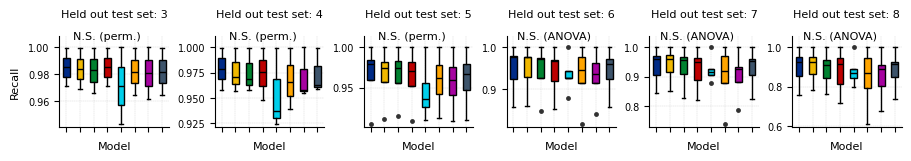

ANOVA SIZE 8 Groups, 9 points in group for f1[train_mutations] 1
### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.322, p = 1.000
ANOVA SIZE 8 Groups, 8 points in group for f1[train_mutations] 2
### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.486, p = 0.999
ANOVA SIZE 8 Groups, 7 points in group for f1[train_mutations] 3
### F = 0.001, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.724, p = 0.998
ANOVA SIZE 8 Groups, 6 points in group for f1[train_mutations] 4
### F = 0.003, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.505, p = 0.999
ANOVA SIZE 8 Groups, 5 points in group for f1[train_mutations] 5
### F = 0.033, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.422, p = 0.985


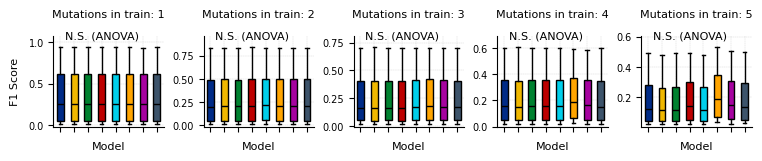

ANOVA SIZE 8 Groups, 2 points in group for f1[test_mutations] 3
Running permutation tests
### F = 0.023, p = 0.241 (permutation) | Kruskal-Wallis H = 1.384, p = nan
ANOVA SIZE 8 Groups, 3 points in group for f1[test_mutations] 4
Running permutation tests
### F = 0.001, p = 0.013 (permutation) | Kruskal-Wallis H = 0.545, p = nan
ANOVA SIZE 8 Groups, 4 points in group for f1[test_mutations] 5
Running permutation tests
### F = 0.003, p = 0.395 (permutation) | Kruskal-Wallis H = 0.353, p = nan
ANOVA SIZE 8 Groups, 5 points in group for f1[test_mutations] 6
### F = 0.015, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.403, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for f1[test_mutations] 7
### F = 0.090, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.487, p = 0.999
ANOVA SIZE 8 Groups, 5 points in group for f1[test_mutations] 8
### F = 0.223, p = 0.977 (ANOVA) | Kruskal-Wallis H = 0.734, p = 0.998


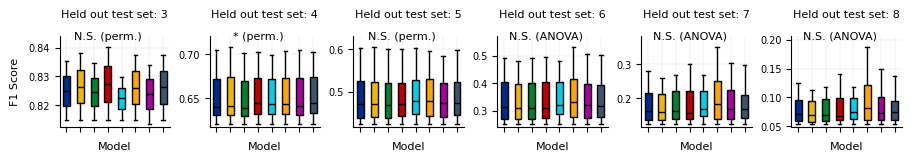

ANOVA SIZE 8 Groups, 9 points in group for roc[train_mutations] 1
### F = 10.764, p = 0.000 (ANOVA) | Kruskal-Wallis H = 39.564, p = 0.000
ANOVA SIZE 8 Groups, 8 points in group for roc[train_mutations] 2
### F = 0.419, p = 0.886 (ANOVA) | Kruskal-Wallis H = 6.209, p = 0.516
ANOVA SIZE 8 Groups, 7 points in group for roc[train_mutations] 3
### F = 0.214, p = 0.980 (ANOVA) | Kruskal-Wallis H = 6.097, p = 0.529
ANOVA SIZE 8 Groups, 6 points in group for roc[train_mutations] 4
### F = 0.047, p = 1.000 (ANOVA) | Kruskal-Wallis H = 2.595, p = 0.920
ANOVA SIZE 8 Groups, 5 points in group for roc[train_mutations] 5
### F = 0.026, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.103, p = 0.993


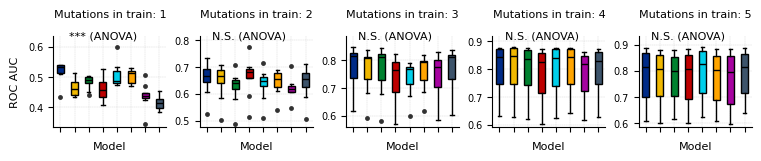

ANOVA SIZE 8 Groups, 2 points in group for roc[test_mutations] 3
Running permutation tests
### F = 0.063, p = 0.984 (permutation) | Kruskal-Wallis H = 2.956, p = nan
ANOVA SIZE 8 Groups, 3 points in group for roc[test_mutations] 4
Running permutation tests
### F = 0.026, p = 0.519 (permutation) | Kruskal-Wallis H = 1.107, p = nan
ANOVA SIZE 8 Groups, 4 points in group for roc[test_mutations] 5
Running permutation tests
### F = 0.023, p = 0.007 (permutation) | Kruskal-Wallis H = 0.807, p = nan
ANOVA SIZE 8 Groups, 5 points in group for roc[test_mutations] 6
### F = 0.029, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.465, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for roc[test_mutations] 7
### F = 0.038, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.191, p = 0.991
ANOVA SIZE 8 Groups, 5 points in group for roc[test_mutations] 8
### F = 0.056, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.490, p = 0.983


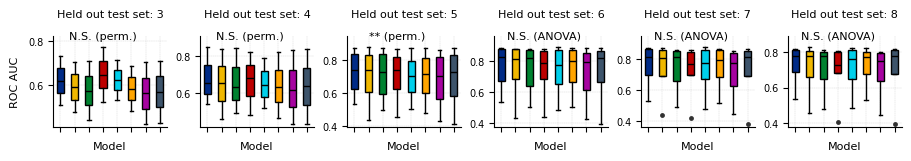

ANOVA SIZE 8 Groups, 9 points in group for accuracy[train_mutations] 1
### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.322, p = 1.000
ANOVA SIZE 8 Groups, 8 points in group for accuracy[train_mutations] 2
### F = 0.175, p = 0.989 (ANOVA) | Kruskal-Wallis H = 6.344, p = 0.500
ANOVA SIZE 8 Groups, 7 points in group for accuracy[train_mutations] 3
### F = 0.768, p = 0.617 (ANOVA) | Kruskal-Wallis H = 13.086, p = 0.070
ANOVA SIZE 8 Groups, 6 points in group for accuracy[train_mutations] 4
### F = 3.736, p = 0.003 (ANOVA) | Kruskal-Wallis H = 18.898, p = 0.009
ANOVA SIZE 8 Groups, 5 points in group for accuracy[train_mutations] 5
### F = 25.271, p = 0.000 (ANOVA) | Kruskal-Wallis H = 33.846, p = 0.000


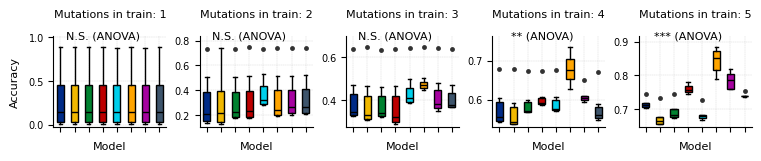

ANOVA SIZE 8 Groups, 2 points in group for accuracy[test_mutations] 3
Running permutation tests
### F = 0.007, p = 0.355 (permutation) | Kruskal-Wallis H = 1.048, p = nan
ANOVA SIZE 8 Groups, 3 points in group for accuracy[test_mutations] 4
Running permutation tests
### F = 0.004, p = 0.150 (permutation) | Kruskal-Wallis H = 0.599, p = nan
ANOVA SIZE 8 Groups, 4 points in group for accuracy[test_mutations] 5
Running permutation tests
### F = 0.008, p = 0.887 (permutation) | Kruskal-Wallis H = 0.247, p = nan
ANOVA SIZE 8 Groups, 5 points in group for accuracy[test_mutations] 6
### F = 0.014, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.368, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for accuracy[test_mutations] 7
### F = 0.042, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.519, p = 0.999
ANOVA SIZE 8 Groups, 5 points in group for accuracy[test_mutations] 8
### F = 0.068, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.675, p = 0.999


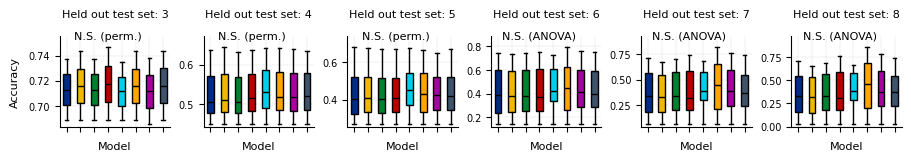

ANOVA SIZE 8 Groups, 9 points in group for top_100_pct[train_mutations] 1
### F = 0.207, p = 0.983 (ANOVA) | Kruskal-Wallis H = 2.836, p = 0.900
ANOVA SIZE 8 Groups, 8 points in group for top_100_pct[train_mutations] 2
### F = 0.261, p = 0.966 (ANOVA) | Kruskal-Wallis H = 2.787, p = 0.904
ANOVA SIZE 8 Groups, 7 points in group for top_100_pct[train_mutations] 3
### F = 0.094, p = 0.998 (ANOVA) | Kruskal-Wallis H = 0.901, p = 0.996
ANOVA SIZE 8 Groups, 6 points in group for top_100_pct[train_mutations] 4
### F = 0.106, p = 0.998 (ANOVA) | Kruskal-Wallis H = 1.398, p = 0.986
ANOVA SIZE 8 Groups, 5 points in group for top_100_pct[train_mutations] 5
### F = 0.027, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.721, p = 0.998


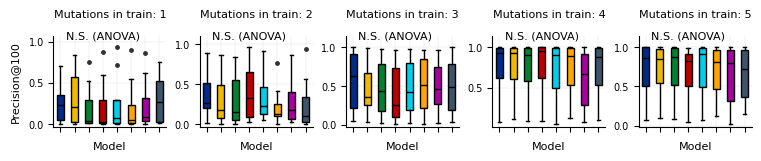

ANOVA SIZE 8 Groups, 2 points in group for top_100_pct[test_mutations] 3
Running permutation tests
### F = 0.174, p = 0.576 (permutation) | Kruskal-Wallis H = 1.756, p = nan
ANOVA SIZE 8 Groups, 3 points in group for top_100_pct[test_mutations] 4
Running permutation tests
### F = 0.094, p = 0.093 (permutation) | Kruskal-Wallis H = 1.933, p = nan
ANOVA SIZE 8 Groups, 4 points in group for top_100_pct[test_mutations] 5
Running permutation tests
### F = 0.054, p = 0.033 (permutation) | Kruskal-Wallis H = 0.705, p = nan
ANOVA SIZE 8 Groups, 5 points in group for top_100_pct[test_mutations] 6
### F = 0.027, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.888, p = 0.996
ANOVA SIZE 8 Groups, 5 points in group for top_100_pct[test_mutations] 7
### F = 0.044, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.072, p = 0.994
ANOVA SIZE 8 Groups, 5 points in group for top_100_pct[test_mutations] 8
### F = 0.036, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.252, p = 0.990


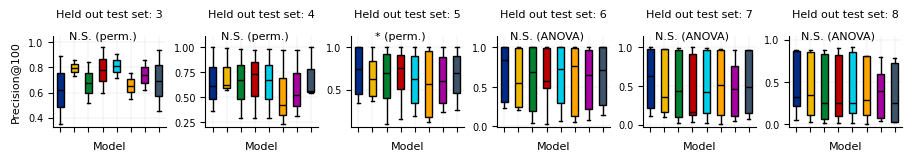


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evaluation

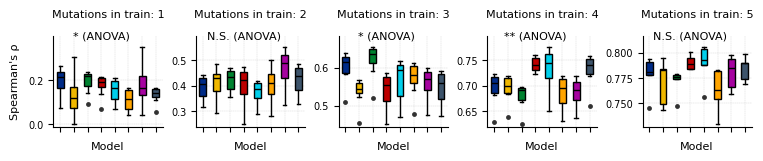

ANOVA SIZE 8 Groups, 2 points in group for correlation[test_mutations] 3
Running permutation tests
### F = 0.087, p = 0.933 (permutation) | Kruskal-Wallis H = 3.265, p = nan
ANOVA SIZE 8 Groups, 3 points in group for correlation[test_mutations] 4
Running permutation tests
### F = 0.067, p = 0.000 (permutation) | Kruskal-Wallis H = 1.693, p = nan
ANOVA SIZE 8 Groups, 4 points in group for correlation[test_mutations] 5
Running permutation tests
### F = 0.046, p = 0.001 (permutation) | Kruskal-Wallis H = 0.795, p = nan
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 6
### F = 0.029, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.738, p = 0.998
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 7
### F = 0.015, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.389, p = 1.000
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 8
### F = 0.010, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.193, p = 1.000


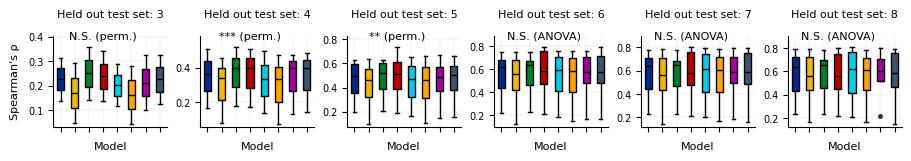


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_ev

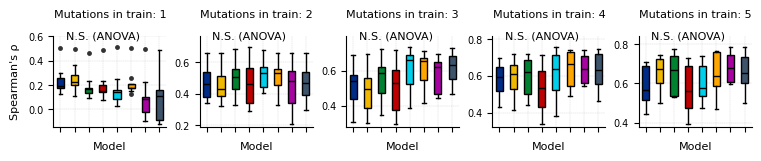

ANOVA SIZE 8 Groups, 2 points in group for correlation[test_mutations] 3
Running permutation tests
### F = 0.002, p = 0.000 (permutation) | Kruskal-Wallis H = 1.368, p = nan
ANOVA SIZE 8 Groups, 3 points in group for correlation[test_mutations] 4
Running permutation tests
### F = 0.008, p = 0.586 (permutation) | Kruskal-Wallis H = 0.667, p = nan
ANOVA SIZE 8 Groups, 4 points in group for correlation[test_mutations] 5
Running permutation tests
### F = 0.015, p = 0.077 (permutation) | Kruskal-Wallis H = 0.812, p = nan
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 6
### F = 0.050, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.361, p = 0.987
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 7
### F = 0.071, p = 0.999 (ANOVA) | Kruskal-Wallis H = 1.806, p = 0.970
ANOVA SIZE 8 Groups, 5 points in group for correlation[test_mutations] 8
### F = 0.109, p = 0.997 (ANOVA) | Kruskal-Wallis H = 3.000, p = 0.885


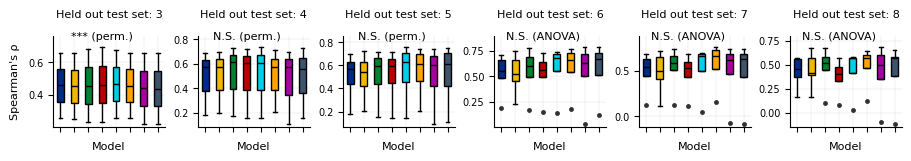

In [105]:
by_subsample_datasets = [
    "lov",
    "pard3",
    "gfp",
    "his",
    "casp"
    ]

features_per_dataset = {
    "gfp": ["precision", "recall", "f1", "roc", "accuracy", "top_100_pct"],
    "lov": ["correlation"],
    "pard3": ["correlation"],
    "his": ["correlation"],
    "casp": ["correlation"]
}

all_dfs = []

fig_path = "./refined_figures/supp_figure_var_analysis/"
os.makedirs(fig_path, exist_ok=True)
for ds in by_subsample_datasets:
    embedding_base_dir = "%s/data/%s/%s_regression_optimal" % (base_path, ds, ds)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    all_dfs.append((ds, df_all, ohe_df_all))
    
    for feature in features_per_dataset[ds]:
        anova_agg = run_mut_comparision_anova_and_plot(
            df=df_all,
            dataset_name=ds,
            feature_name=feature,
            mutations=[1, 2, 3, 4, 5],
            mutation_factor_colname="train_mutations",
            results=anova_agg,
            do_plot=True,
            verbose=True,
            train=True,
            fig_path=os.path.join(fig_path, f"{ds}_{feature}_train_mutations.svg")
        )

        anova_agg = run_mut_comparision_anova_and_plot(
            df=df_all,
            dataset_name=ds,
            feature_name=feature,
            mutations=[3,4,5,6,7,8],
            mutation_factor_colname="test_mutations",
            results=anova_agg,
            do_plot=True,
            verbose=True,
            train=False,
            
            fig_path=os.path.join(fig_path, f"{ds}_{feature}_test_mutations.svg")
        )


In [106]:
df_all

,correlation,p_value,test_mutations,train_mutations,classifier,model_name,clf_type,model
0,0.739987,0.000000e+00,6,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
1,0.686927,9.574517e-56,7,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
2,0.576417,8.801636e-28,8,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
3,0.536801,3.418123e-18,9,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
4,0.473438,1.344075e-10,10,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
...,...,...,...,...,...,...,...,...
275,0.660914,6.257654e-297,6,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
276,0.650150,3.202158e-48,7,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
277,0.564941,1.591064e-26,8,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
278,0.517111,8.728977e-17,9,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m


In [107]:
#working_df["model_name"].unique()


var_explained_factor_results = []
for dataset_name, df_all, ohe_df_all in all_dfs:


    features_to_calculate_variance_for = features_per_dataset[dataset_name]
    working_df_pre_subset = df_all

    working_df = working_df_pre_subset[working_df_pre_subset["test_mutations"] <= 8]


    working_df["scale"] = np.nan

    for model_name in working_df["model_name"].unique():
        working_df.loc[working_df["model_name"] == model_name, "scale"] = discretized_parameter_scale[model_name]

    

    for tm in range(3, 9):
        sub_df = working_df[(working_df["test_mutations"] == tm) & (working_df["train_mutations"] >= 1)]
        ss_all, results_df = calculate_ss_for_df_and_factors(
            sub_df,
            factors=["model_name", "train_mutations", "scale"],
            variables_to_calculate=features_to_calculate_variance_for
        )

        for var in features_to_calculate_variance_for:#
            for factor in ["model_name", "train_mutations", "scale"]:
                ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
                total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
                

                var_explained_factor_results.append({"dataset": dataset_name,
                                                    "var": var, 
                                                    "factor": factor, 
                                                    "test_mutations": tm, 
                                                    "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})


/tmp/ipykernel_694596/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_df["scale"] = np.nan
/tmp/ipykernel_694596/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_df["scale"] = np.nan
/tmp/ipykernel_694596/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [108]:

pd.DataFrame(var_explained_factor_results)

,dataset,var,factor,test_mutations,var_explained
0,lov,correlation,model_name,3,0.004965
1,lov,correlation,train_mutations,3,0.986858
2,lov,correlation,scale,3,0.002138
3,lov,correlation,model_name,4,0.005417
4,lov,correlation,train_mutations,4,0.980330
...,...,...,...,...,...
175,casp,correlation,train_mutations,7,0.949174
176,casp,correlation,scale,7,0.004871
177,casp,correlation,model_name,8,0.023212
178,casp,correlation,train_mutations,8,0.908048


In [109]:

nmt_base_path = "%s/data/nmt/results/by_complexity_and_budget_up_to_11/" % base_path
gcn_base_path = "%s/data/gcn4/results/by_complexity_and_budget_up_to_8/" % base_path




nmt_sets = load_df_with_budget(nmt_base_path)
nmt_train = [5,6,7,8,9]
nmt_test = [9, 10, 11]

gcn_sets = load_df_with_budget(gcn_base_path)
gcn_train = [3,4,5,6]
gcn_test = [6, 7, 8]






In [110]:
factors = ["model_name", "budget", "max_muts_in_train"]

vars_and_func = {"gcn4" : lambda v: v.median(),
                 "nmt" : lambda v: np.percentile(v, 85)}#,


discretized_parameter_scale = {"esm_35m": "0_100",
                                "esm_8m": "0_100",
                                "esm_150m": "100_500",
                                "esm_650m": "500_1000",
                                "esm_3b": "500_1000",
                                "progen2-small": "100_500",
                                "progen2-medium": "500_1000",
                                "prot_bert": "100_500"}




results = []

all_sets = [("gcn4", gcn_sets), ("nmt", nmt_sets)]

for dataset_name, sets in all_sets:
    for held_out_set, df_tmp in sets.items():

        models = df_tmp["model_name"].unique()
        models = models[models != "one_hot"]
        
        #df_tmp = df[df["set_name"] == held_out_set]
        muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
        budgets_sorted = sorted(df_tmp["budget"].unique())

        for model_name in models:
            df_tmp_model = df_tmp[df_tmp["model_name"] == model_name]
            
            for b in budgets_sorted:
                for m in muts_sorted:
                    vals = df_tmp_model[(df_tmp_model["budget"] == b) & (
                                        df_tmp_model["max_muts_in_train"] == m)]["cor_llm"]

                    print(np.abs(vals))
                                        
                    metadata = {"model_name": model_name, 
                                "budget": b, 
                                "max_muts_in_train": m, 
                                #"muts_budget": f"m_{m}_b_{b}",
                                #"muts_model": f"m_{m}_mdl_{model_name}",
                                #"budget_model": f"b_{b}_mdl_{model_name}",
                                "dataset": dataset_name,
                                "set": held_out_set,
                                "scale": discretized_parameter_scale[model_name],
                                "cor_llm": vars_and_func[dataset_name]((vals))}

                    #statistics = {var: vars_and_func[var](vals) for var in vars}
                    results.append({**metadata})


rsdf =  pd.DataFrame(results)



0     0.290179
1     0.011670
2     0.220473
3     0.383342
4     0.167659
5     0.043818
6     0.260770
7     0.160582
8     0.189023
9     0.117415
10    0.140294
11    0.281222
12    0.271524
13    0.121275
14    0.268680
15    0.276672
16    0.268034
17    0.150147
18    0.205541
19    0.334651
20    0.136124
21    0.102916
22    0.136022
23    0.042336
24    0.148437
25    0.206816
26    0.060050
27    0.218882
28    0.066658
29    0.218825
Name: cor_llm, dtype: float64
180    0.103172
181    0.096714
182    0.121831
183    0.033097
184    0.032141
185    0.355000
186    0.204485
187    0.245583
188    0.208923
189    0.181736
190    0.287548
191    0.340260
192    0.210711
193    0.126630
194    0.023982
195    0.318615
196    0.299275
197    0.260284
198    0.098217
199    0.162889
200    0.025932
201    0.067628
202    0.165482
203    0.257822
204    0.084854
205    0.136867
206    0.218009
207    0.161560
208    0.103507
209    0.108361
Name: cor_llm, dtype: float64
360    0.0

In [111]:

var_explained_factor_results_with_budget = []
features = ["cor_llm"]
extended_factors = np.concatenate([factors, ["scale"]])  # , "muts_budget", "muts_model", "budget_model"]

# Updated to work for multiple datasets in rsdf
for dataset_name in rsdf["dataset"].unique():
    dataset_df = rsdf[rsdf["dataset"] == dataset_name]
    for held_out_set in dataset_df["set"].unique():
        print(held_out_set)
        ss_all, results_df = calculate_ss_for_df_and_factors(
            dataset_df[dataset_df["set"] == held_out_set],
            factors=extended_factors,
            variables_to_calculate=features
        )

        for var in features:
            for factor in extended_factors:
                ss_factor_for_var = results_df[
                    (results_df["factor_name"] == factor) & (results_df["var"] == var)
                ]["SS"].sum()
                total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]

                var_explained_factor_results_with_budget.append({
                    "dataset": dataset_name,
                    "var": var,
                    "factor": factor,
                    "test_mutations": int(held_out_set.split("_")[-1]),
                    "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()
                })


held_out_6
held_out_7
held_out_8
held_out_9
held_out_10
held_out_11


In [112]:
df_var_all = pd.concat(
    [pd.DataFrame(var_explained_factor_results),
     pd.DataFrame(var_explained_factor_results_with_budget)]
)

ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 5
Running permutation tests


/tmp/ipykernel_694596/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_694596/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_694596/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will def

### F = 2.316, p = 0.253 (permutation) | Kruskal-Wallis H = 11.947, p = nan
ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 6
Running permutation tests
### F = 0.805, p = 0.583 (permutation) | Kruskal-Wallis H = 5.773, p = nan
ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 7
Running permutation tests
### F = 2.556, p = 0.062 (permutation) | Kruskal-Wallis H = 11.053, p = nan
ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 8
Running permutation tests
### F = 0.460, p = 0.533 (permutation) | Kruskal-Wallis H = 3.587, p = nan
ANOVA SIZE 8 Groups, 2 points in group for cor_llm[max_muts_in_train] 9
Running permutation tests
### F = 0.066, p = 0.007 (permutation) | Kruskal-Wallis H = 3.265, p = nan


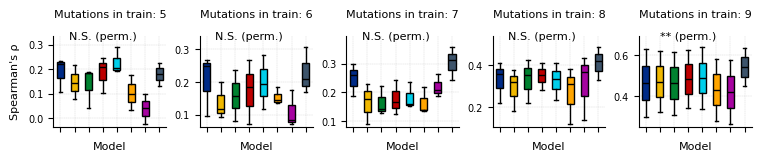

ANOVA SIZE 8 Groups, 4 points in group for cor_llm[set] 9
Running permutation tests
### F = 0.509, p = 0.542 (permutation) | Kruskal-Wallis H = 6.432, p = nan
ANOVA SIZE 8 Groups, 5 points in group for cor_llm[set] 10
### F = 0.137, p = 0.995 (ANOVA) | Kruskal-Wallis H = 3.931, p = 0.788
ANOVA SIZE 8 Groups, 6 points in group for cor_llm[set] 11
### F = 0.852, p = 0.552 (ANOVA) | Kruskal-Wallis H = 5.393, p = 0.612


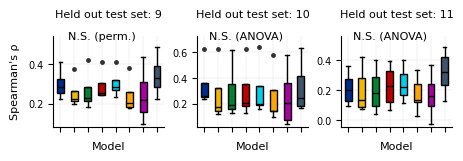

/tmp/ipykernel_694596/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_694596/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_694596/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Eithe

ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 3
Running permutation tests
### F = 0.809, p = 0.145 (permutation) | Kruskal-Wallis H = 6.307, p = nan
ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 4
Running permutation tests
### F = 1.309, p = 0.392 (permutation) | Kruskal-Wallis H = 9.307, p = nan
ANOVA SIZE 8 Groups, 3 points in group for cor_llm[max_muts_in_train] 5
Running permutation tests
### F = 0.717, p = 0.057 (permutation) | Kruskal-Wallis H = 5.719, p = nan
ANOVA SIZE 8 Groups, 2 points in group for cor_llm[max_muts_in_train] 6
Running permutation tests
### F = 19.933, p = 0.779 (permutation) | Kruskal-Wallis H = 13.147, p = nan


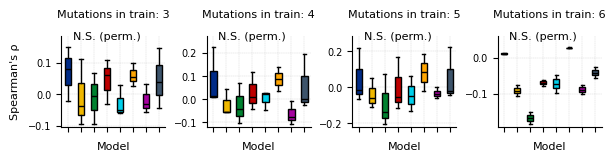

ANOVA SIZE 8 Groups, 3 points in group for cor_llm[set] 6
Running permutation tests
### F = 14.362, p = 0.050 (permutation) | Kruskal-Wallis H = 19.987, p = nan
ANOVA SIZE 8 Groups, 4 points in group for cor_llm[set] 7
Running permutation tests
### F = 10.130, p = 0.172 (permutation) | Kruskal-Wallis H = 23.749, p = nan
ANOVA SIZE 8 Groups, 5 points in group for cor_llm[set] 8
### F = 6.271, p = 0.000 (ANOVA) | Kruskal-Wallis H = 21.122, p = 0.004


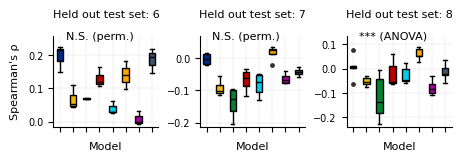

In [113]:

budgeted_sets = [
    ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
    ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
]


for name, sets, train, test, group_func in budgeted_sets:
    all_dfs = []
    for set_name, set_df in sets.items():
        grouped_df = group_func(set_df)
        grouped_df["set"] = int(set_name.split("_")[-1])
        all_dfs.append(grouped_df)
    all_dfs = pd.concat(all_dfs)
    all_dfs = all_dfs[all_dfs["model_name"] != "one_hot"]
    anova_agg = run_mut_comparision_anova_and_plot(
        df=all_dfs,
        dataset_name=name,
        feature_name="cor_llm",
        mutations=train,
        mutation_factor_colname="max_muts_in_train",
        results=anova_agg,
        do_plot=True,
        verbose=True,
        train=True,
        fig_path=os.path.join(fig_path, f"{name}_train_mutations.svg")
    )
    anova_agg = run_mut_comparision_anova_and_plot(
        df=all_dfs,
        dataset_name=name,
        feature_name="cor_llm",
        mutations=test,
        mutation_factor_colname="set",
        results=anova_agg,
        do_plot=True,
        verbose=True,
        train=False,
        fig_path=os.path.join(fig_path, f"{name}_test_mutations.svg")
    )



In [114]:
final_pvalue_df = pd.DataFrame(anova_agg)

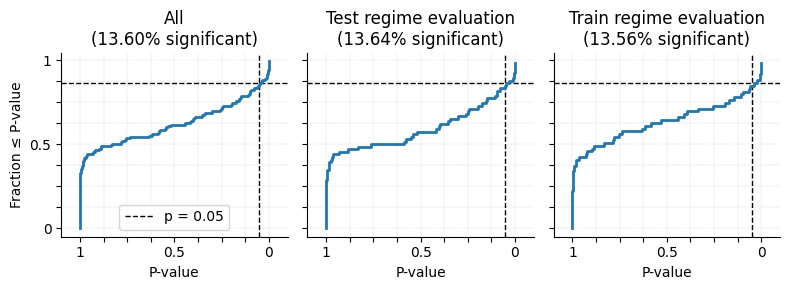

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

for ax, df, title in zip(axes, dfs, titles):
    pvalues = df["P_value"].dropna().sort_values()
    cumulative = 1 - np.arange(1, len(pvalues) + 1) / len(pvalues)
    portion = 1 - sum(pvalues < 0.05) / len(pvalues)
    ax.set_xlabel("P-value")
    ax.set_title("%s\n(%.2f%% significant)" % (title, (1 - portion) * 100))
    ax.set_xticks([1, 0.5, 0])
    ax.set_xticklabels(['1', '0.5', '0'])
    ax.set_yticks([1, 0.5, 0])
    ax.set_yticklabels(['1', '0.5', '0'])
    ax.axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
    if len(pvalues) > 0:
        ax.axhline(portion, color='k', linestyle='dashed', lw=1)
    ax.set_xlim(1.1, -0.1)
    ax.step(pvalues[::-1], cumulative[::-1], where="post", lw=2)
    ax.xaxis.set_major_locator(MultipleLocator(0.125))    
    ax.yaxis.set_major_locator(MultipleLocator(0.125))
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)

axes[0].set_ylabel("Fraction ≤ P-value")
axes[0].legend()
plt.tight_layout()

# Save the figure to the specified figure path as SVG with font type saved as 'font'
plt.savefig(os.path.join(fig_path, "pvalue_fractions_new.svg"), format="svg")
plt.show()


In [116]:
# fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

# dfs = [
#     final_pvalue_df,
#     final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
#     final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
# ]

# titles = [
#     "All",
#     "Test regime evaluation",
#     "Train regime evaluation"
# ]

# for ax, df, title in zip(axes, dfs, titles):
#     kruskal_pvalues = df["Kruskal_P"].dropna().sort_values()
#     cumulative = 1 - np.arange(1, len(kruskal_pvalues) + 1) / len(kruskal_pvalues)
#     portion = 1 - sum(kruskal_pvalues < 0.05) / len(kruskal_pvalues)
#     ax.set_xlabel("Kruskal-Wallis P-value")
#     ax.set_title("%s\n(%.2f%% significant)" % (title, (1 - portion) * 100))
#     ax.set_xticks([1, 0.5, 0])
#     ax.set_xticklabels(['1', '0.5', '0'])
#     ax.set_yticks([1, 0.5, 0])
#     ax.set_yticklabels(['1', '0.5', '0'])
#     ax.axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
#     if len(kruskal_pvalues) > 0:
#         ax.axhline(portion, color='k', linestyle='dashed', lw=1)
#     ax.set_xlim(1.1, -0.1)
#     ax.step(kruskal_pvalues[::-1], cumulative[::-1], where="post", lw=2)
#     ax.xaxis.set_major_locator(MultipleLocator(0.125))    
#     ax.yaxis.set_major_locator(MultipleLocator(0.125))
#     ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
#     spines = ax.spines
#     spines['right'].set_visible(False)
#     spines['top'].set_visible(False)

# axes[0].set_ylabel("Fraction ≤ Kruskal-Wallis P-value")
# axes[0].legend()
# plt.tight_layout()

# # Save the figure to the specified figure path
# #fig.savefig(os.path.join(fig_path, "kruskal_pvalue_fractions.png"), dpi=300)
# plt.show()


In [117]:
(final_pvalue_df["P_value"] < 0.05).sum() / len(final_pvalue_df)

0.136

In [118]:
final_pvalue_df

,feature,comparison_type,mutations,dataset,test_type,F_value,P_value,Kruskal_H,Kruskal_P
0,correlation,train,1,lov,ANOVA,6.922180,0.000004,30.572806,0.000075
1,correlation,train,2,lov,ANOVA,1.044628,0.411133,6.444231,0.488938
2,correlation,train,3,lov,ANOVA,0.747416,0.633317,5.209452,0.634420
3,correlation,train,4,lov,ANOVA,1.004175,0.442783,6.068027,0.531829
4,correlation,train,5,lov,ANOVA,0.620112,0.735322,4.012683,0.778315
...,...,...,...,...,...,...,...,...,...
120,cor_llm,train,5,gcn,permutation,0.717456,0.057400,5.719153,NaN
121,cor_llm,train,6,gcn,permutation,19.932512,0.779500,13.147059,NaN
122,cor_llm,test,6,gcn,permutation,14.362147,0.050100,19.986667,NaN
123,cor_llm,test,7,gcn,permutation,10.130312,0.172300,23.748762,NaN


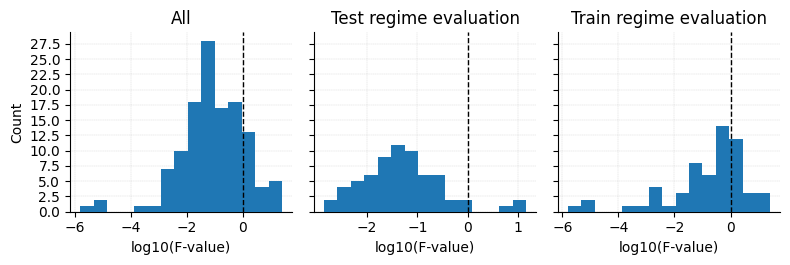

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2.75), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

xlabelticks = [
    [-6, -4, -2, 0],
    [-2, -1,  0, 1],
    [-6, -4, -2, 0]
]

for ax, df, title, xlabelticks in zip(axes, dfs, titles, xlabelticks):
    fvalues = np.log10(df["F_value"].dropna())
    # Plot the histogram first, so grid overlays it
    ax.hist(fvalues, bins=15, zorder=3)
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)
    ax.set_xlabel("log10(F-value)")
    ax.axvline(0, lw="1", color="k", linestyle="dashed", zorder=3)
    ax.set_title(title)
    
    ax.set_xticks(xlabelticks)
    
    ax.yaxis.set_major_locator(MultipleLocator(2.5))    
    #ax.xaxis.set_major_locator(MultipleLocator(1))
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "f_value_distribution_new.svg"))
plt.show()


In [120]:
# fig, axes = plt.subplots(1, 3, figsize=(8, 2.75), sharey=True)

# dfs = [
#     final_pvalue_df,
#     final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
#     final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
# ]

# titles = [
#     "All",
#     "Test regime evaluation",
#     "Train regime evaluation"
# ]

# xlabelticks = [
#     [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
#     [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
#     [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
# ]

# for ax, df, title, xticks in zip(axes, dfs, titles, xlabelticks):
#     hvalues = df["Kruskal_H"].dropna()
#     # Plot the histogram first, so grid overlays it
#     ax.hist(hvalues, bins=15, zorder=3)
#     ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
#     spines = ax.spines
#     spines['right'].set_visible(False)
#     spines['top'].set_visible(False)
#     ax.set_xlabel("Kruskal H statistic")
#     ax.set_title(title)
#     ax.set_xticks(xticks)
#     ax.yaxis.set_major_locator(MultipleLocator(2.5))
# axes[0].set_ylabel("Count")
# plt.tight_layout()
# #fig.savefig(os.path.join(fig_path, "kruskal_H_distribution.png"), dpi=300)
# plt.show()


/tmp/ipykernel_694596/2845300950.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


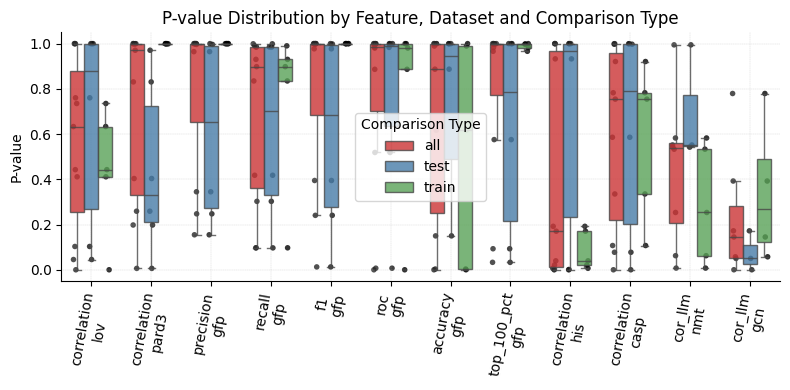

In [121]:

plt.figure(figsize=(8, 4))

combo = final_pvalue_df[["feature", "dataset"]].drop_duplicates()
feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

plot_df = []
for fd in feature_dataset_order:
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["all", "test", "train"]:
        if comp_type == "all":
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset)
        else:
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset) & (final_pvalue_df["comparison_type"] == comp_type)
        for val in final_pvalue_df.loc[mask, "P_value"]:
            plot_df.append({
                "feature_dataset": fd,
                "comparison_type": comp_type,
                "P_value": (val)
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["all", "test", "train"])]


# First draw boxplot
box = sns.boxplot(
    x="feature_dataset",
    y="P_value",
    hue="comparison_type",
    data=plot_df,
    order=feature_dataset_order,
    hue_order=["all", "test", "train"],
    width=0.7,
    dodge=True,
    palette="Set1",
    showfliers=False  # remove hollow outlier markers
    # zorder will not help as boxplot is artistically behind by default
)

# then draw stripplot, but move under boxplot using zorder and legend=False to avoid legend duplication
sns.stripplot(
    x="feature_dataset",
    y="P_value",
    hue="comparison_type",
    data=plot_df,
    order=feature_dataset_order,
    hue_order=["all", "test", "train"],
    dodge=True,
    marker="o",
    color="black",
    size=4,
    alpha=0.8,
    linewidth=0,
    zorder=0,      # puts below boxplot
    legend=False   # avoids duplicate legend handles
)

# Set boxplot opacity to 0.5 for all boxes and lines
for patch in box.patches:
    patch.set_alpha(0.8)

for line in box.lines:
    line.set_alpha(0.8)



plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=80)
plt.ylabel("P-value")
plt.xlabel("")
plt.title("P-value Distribution by Feature, Dataset and Comparison Type")
# Adjust legend to avoid duplicate handles/labels
handles, labels = plt.gca().get_legend_handles_labels()
n = len(set(plot_df["comparison_type"]))
plt.legend(handles[:n], labels[:n], title="Comparison Type")
plt.tight_layout()
plt.show()


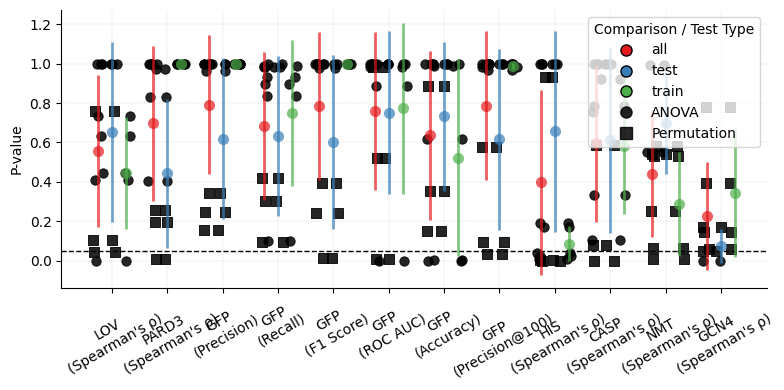

In [148]:

# Consistent naming as in file_context_0
final_pvalue_df = final_pvalue_df.copy()
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gfp", "dataset"] = "GFP"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "pard3", "dataset"] = "PARD3"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "nmt", "dataset"] = "NMT"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gcn", "dataset"] = "GCN4"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "lov", "dataset"] = "LOV"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "his", "dataset"] = "HIS"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "casp", "dataset"] = "CASP"

plt.figure(figsize=(8, 4))

# Prepare label mapping for pretty axis labels as in file_context_0
combo = final_pvalue_df[["feature", "dataset"]].drop_duplicates()

try:
    display_label_dict = ylabel_dict
except NameError:
    display_label_dict = {}

feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

def get_ylabel(feat):
    return display_label_dict.get(feat, feat.replace("_", " ").title())

feature_dataset_order_y_label = combo.apply(
    lambda row: f"{row['dataset']}\n({get_ylabel(row['feature'])})", axis=1
)

plot_order = feature_dataset_order
plot_xticks = feature_dataset_order_y_label

plot_df = []
for fd, pretty_label in zip(plot_order, plot_xticks):
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["all", "test", "train"]:
        if comp_type == "all":
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset)
        else:
            mask = (
                (final_pvalue_df["feature"] == feature)
                & (final_pvalue_df["dataset"] == dataset)
                & (final_pvalue_df["comparison_type"] == comp_type)
            )
        idxs = final_pvalue_df.loc[mask].index
        for idx in idxs:
            val = final_pvalue_df.at[idx, "P_value"]
            test_type = final_pvalue_df.at[idx, "test_type"] if "test_type" in final_pvalue_df.columns else None
            plot_df.append({
                "feature_dataset": fd,
                "feature_dataset_y": pretty_label,
                "comparison_type": comp_type,
                "P_value": val,
                "test_type": test_type.lower() if isinstance(test_type, str) else None
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["all", "test", "train"])]
plot_df = plot_df[plot_df["feature_dataset"].isin(plot_order)]

# Compute summary statistics per feature_dataset and comparison_type
summary = plot_df.groupby(['feature_dataset', 'comparison_type'])['P_value'].agg(
    mean='mean', std='std'
).reset_index()

comparison_types = ["all", "test", "train"]
colors = sns.color_palette('Set1', n_colors=3)
color_map = dict(zip(comparison_types, colors))

width = 0.25
dodge_pos = dict(zip(comparison_types, [-width, 0, width]))

# Plot mean/std (errorbar) per type in colored dots, overlaid with scatter of all points, style by test_type
for i, (fd, pretty_label) in enumerate(zip(plot_order, plot_xticks)):
    for comp_type in comparison_types:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['comparison_type'] == comp_type)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            i + dodge_pos[comp_type], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[comp_type],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            label=comp_type if (i == 0) else "",
            zorder=4
        )

# Marker dict: 'anova' -> 'o' (circle), 'permutation' -> 's' (square)
# Both solid black
marker_dict = {"anova": "o", "permutation": "s", None: "o"}
label_dict = {"anova": "ANOVA", "permutation": "Permutation"}

scatter_legend_handles = {}
# Draw all points individually, grouping by test_type for style
for i, fd in enumerate(plot_order):
    for ci, comp_type in enumerate(comparison_types):
        pts = plot_df[
            (plot_df["feature_dataset"] == fd) &
            (plot_df["comparison_type"] == comp_type)
        ]
        # group by test_type so we can draw with a consistent style
        for tt in pts["test_type"].unique():
            pts_tt = pts[pts["test_type"] == tt]
            if pts_tt.empty:
                continue
            xpos = i + dodge_pos[comp_type] + np.random.uniform(-0.09, 0.09, len(pts_tt))
            y = pts_tt["P_value"].values
            marker = marker_dict.get(tt, "o")
            # Solid black marker for both styles. edgecolors to 'black' as well.
            hdl = plt.scatter(
                xpos, y,
                s=45,
                marker=marker,
                color="black",
                alpha=0.85,
                linewidth=0.7,
                edgecolors='black',
                zorder=3,
                label=None
            )
            # For legend: only add 1st handle per test_type
            if tt not in scatter_legend_handles:
                scatter_legend_handles[tt] = hdl

plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(
    range(len(plot_order)),
    plot_xticks,
    rotation=30
)
plt.ylabel("P-value")
plt.xlabel("")
plt.axhline(0.05, color='k', linestyle='dashed', lw=1)

# Compose legend for test_type
from matplotlib.lines import Line2D

custom_legend = []
ordered_types = ['anova', 'permutation']
for tt in ordered_types:
    if tt in scatter_legend_handles:
        custom_legend.append(
            Line2D(
                [0], [0],
                marker=marker_dict[tt],
                color='black',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=8,
                alpha=0.85,
                linestyle='None',
                label=label_dict[tt]
            )
        )

# Add also the comparison type legend by overlaying points of the main colors
comp_type_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[comp_type],
        markeredgecolor="black",
        markersize=8,
        linestyle='None',
        label=comp_type
    )
    for comp_type in comparison_types
]

plt.legend(
    handles=comp_type_legend + custom_legend,
    title="Comparison / Test Type",
    loc='best'
)
plt.tight_layout()
# Save the figure to the specified figure path as SVG with font type saved as 'font'
plt.savefig(os.path.join(fig_path, "pvalue_dist_non_corrected_new.svg"), format="svg")
plt.show()


In [149]:
# Perform FDR correction on the P_value column, add as new column 'FDR_corrected'
final_pvalue_df["FDR_corrected"] = fdr_bh(final_pvalue_df["P_value"].values)

final_pvalue_df["FDR_corrected"] 


0      0.000098
1      1.000000
2      1.000000
3      1.000000
4      1.000000
         ...   
120    0.377632
121    1.000000
122    0.347917
123    0.694758
124    0.002348
Name: FDR_corrected, Length: 125, dtype: float64

In [150]:
# Perform FDR correction on train and test subsets separately, after dropping null P_values
# and assign the adjusted values back to the same FDR_corrected column as the main correction

# Train subset FDR correction and assignment
train_mask = (final_pvalue_df["comparison_type"] == "train") & (~final_pvalue_df["P_value"].isnull())
train_pvalues = final_pvalue_df.loc[train_mask, "P_value"].values
train_fdr_corrected = fdr_bh(train_pvalues)
final_pvalue_df.loc[train_mask, "FDR_corrected"] = train_fdr_corrected

# Test subset FDR correction and assignment
test_mask = (final_pvalue_df["comparison_type"] == "test") & (~final_pvalue_df["P_value"].isnull())
test_pvalues = final_pvalue_df.loc[test_mask, "P_value"].values
test_fdr_corrected = fdr_bh(test_pvalues)
final_pvalue_df.loc[test_mask, "FDR_corrected"] = test_fdr_corrected

In [151]:
sum(final_pvalue_df["FDR_corrected"] < 0.05)

8

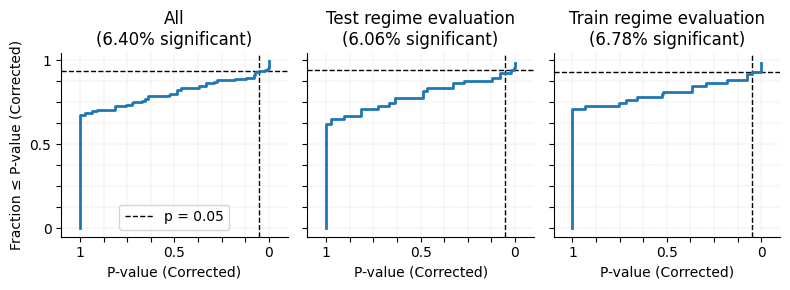

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

for ax, df, title in zip(axes, dfs, titles):
    pvalues = df["FDR_corrected"].dropna().sort_values()
    cumulative = 1 - np.arange(1, len(pvalues) + 1) / len(pvalues)
    portion = 1 - sum(pvalues < 0.05) / len(pvalues)
    ax.set_xlabel("P-value (Corrected)")
    ax.set_title("%s\n(%.2f%% significant)" % (title, (1 - portion) * 100))
    ax.set_xticks([1, 0.5, 0])
    ax.set_xticklabels(['1', '0.5', '0'])
    ax.set_yticks([1, 0.5, 0])
    ax.set_yticklabels(['1', '0.5', '0'])
    ax.axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
    if len(pvalues) > 0:
        ax.axhline(portion, color='k', linestyle='dashed', lw=1)
    ax.set_xlim(1.1, -0.1)
    ax.step(pvalues[::-1], cumulative[::-1], where="post", lw=2)
    ax.xaxis.set_major_locator(MultipleLocator(0.125))    
    ax.yaxis.set_major_locator(MultipleLocator(0.125))
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)

axes[0].set_ylabel("Fraction ≤ P-value (Corrected)")
axes[0].legend()
plt.tight_layout()

# Save the figure to the specified figure path as SVG with font type saved as 'font'
plt.savefig(os.path.join(fig_path, "pvalue_fractions_corrected_fdr_new.svg"), format="svg")
plt.show()


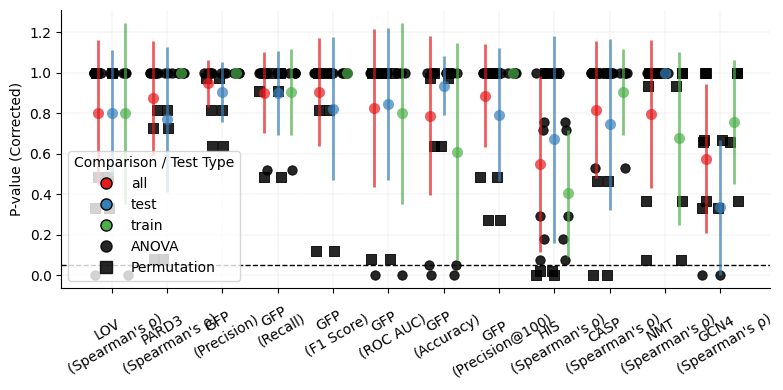

In [153]:
# Consistent naming as in file_context_0
final_pvalue_df = final_pvalue_df.copy()
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gfp", "dataset"] = "GFP"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "pard3", "dataset"] = "PARD3"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "nmt", "dataset"] = "NMT"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gcn", "dataset"] = "GCN4"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "lov", "dataset"] = "LOV"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "his", "dataset"] = "HIS"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "casp", "dataset"] = "CASP"

plt.figure(figsize=(8, 4))

# Prepare label mapping for pretty axis labels as in file_context_0
combo = final_pvalue_df[["feature", "dataset"]].drop_duplicates()

try:
    display_label_dict = ylabel_dict
except NameError:
    display_label_dict = {}

feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

def get_ylabel(feat):
    return display_label_dict.get(feat, feat.replace("_", " ").title())

feature_dataset_order_y_label = combo.apply(
    lambda row: f"{row['dataset']}\n({get_ylabel(row['feature'])})", axis=1
)

plot_order = feature_dataset_order
plot_xticks = feature_dataset_order_y_label

plot_df = []
for fd, pretty_label in zip(plot_order, plot_xticks):
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["all", "test", "train"]:
        if comp_type == "all":
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset)
        else:
            mask = (
                (final_pvalue_df["feature"] == feature)
                & (final_pvalue_df["dataset"] == dataset)
                & (final_pvalue_df["comparison_type"] == comp_type)
            )
        idxs = final_pvalue_df.loc[mask].index
        for idx in idxs:
            val = final_pvalue_df.at[idx, "FDR_corrected"]
            test_type = final_pvalue_df.at[idx, "test_type"] if "test_type" in final_pvalue_df.columns else None
            plot_df.append({
                "feature_dataset": fd,
                "feature_dataset_y": pretty_label,
                "comparison_type": comp_type,
                "P_value": val,
                "test_type": test_type.lower() if isinstance(test_type, str) else None
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["all", "test", "train"])]
plot_df = plot_df[plot_df["feature_dataset"].isin(plot_order)]

# Compute summary statistics per feature_dataset and comparison_type
summary = plot_df.groupby(['feature_dataset', 'comparison_type'])['P_value'].agg(
    mean='mean', std='std'
).reset_index()

comparison_types = ["all", "test", "train"]
colors = sns.color_palette('Set1', n_colors=3)
color_map = dict(zip(comparison_types, colors))

width = 0.25
dodge_pos = dict(zip(comparison_types, [-width, 0, width]))

# Plot mean/std (errorbar) per type in colored dots, overlaid with scatter of all points, style by test_type
for i, (fd, pretty_label) in enumerate(zip(plot_order, plot_xticks)):
    for comp_type in comparison_types:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['comparison_type'] == comp_type)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            i + dodge_pos[comp_type], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[comp_type],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            label=comp_type if (i == 0) else "",
            zorder=4
        )

# Marker dict: 'anova' -> 'o' (circle), 'permutation' -> 's' (square)
# Both solid black
marker_dict = {"anova": "o", "permutation": "s", None: "o"}
label_dict = {"anova": "ANOVA", "permutation": "Permutation"}

scatter_legend_handles = {}
# Draw all points individually, grouping by test_type for style
for i, fd in enumerate(plot_order):
    for ci, comp_type in enumerate(comparison_types):
        pts = plot_df[
            (plot_df["feature_dataset"] == fd) &
            (plot_df["comparison_type"] == comp_type)
        ]
        # group by test_type so we can draw with a consistent style
        for tt in pts["test_type"].unique():
            pts_tt = pts[pts["test_type"] == tt]
            if pts_tt.empty:
                continue
            xpos = i + dodge_pos[comp_type] + np.random.uniform(-0.09, 0.09, len(pts_tt))
            y = pts_tt["P_value"].values
            marker = marker_dict.get(tt, "o")
            # Solid black marker for both styles. edgecolors to 'black' as well.
            hdl = plt.scatter(
                xpos, y,
                s=45,
                marker=marker,
                color="black",
                alpha=0.85,
                linewidth=0.7,
                edgecolors='black',
                zorder=3,
                label=None
            )
            # For legend: only add 1st handle per test_type
            if tt not in scatter_legend_handles:
                scatter_legend_handles[tt] = hdl

plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(
    range(len(plot_order)),
    plot_xticks,
    rotation=30
)
plt.ylabel("P-value (Corrected)")
plt.xlabel("")
plt.axhline(0.05, color='k', linestyle='dashed', lw=1)

# Compose legend for test_type
from matplotlib.lines import Line2D

custom_legend = []
ordered_types = ['anova', 'permutation']
for tt in ordered_types:
    if tt in scatter_legend_handles:
        custom_legend.append(
            Line2D(
                [0], [0],
                marker=marker_dict[tt],
                color='black',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=8,
                alpha=0.85,
                linestyle='None',
                label=label_dict[tt]
            )
        )

# Add also the comparison type legend by overlaying points of the main colors
comp_type_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[comp_type],
        markeredgecolor="black",
        markersize=8,
        linestyle='None',
        label=comp_type
    )
    for comp_type in comparison_types
]

plt.legend(
    handles=comp_type_legend + custom_legend,
    title="Comparison / Test Type",
    loc='best'
)
plt.tight_layout()
# Save the figure to the specified figure path as SVG with font type saved as 'font'
plt.savefig(os.path.join(fig_path, "pvalue_dist_corrected_fdr_new.svg"), format="svg")
plt.show()


In [154]:
df_var_all.loc[df_var_all["factor"] == "max_muts_in_train", "factor"] = "train_mutations"
df_var_all.loc[df_var_all["dataset"] == "gfp", "dataset"] = "GFP"
df_var_all.loc[df_var_all["dataset"] == "pard3", "dataset"] = "PARD3"
df_var_all.loc[df_var_all["dataset"] == "nmt", "dataset"] = "NMT"
df_var_all.loc[df_var_all["dataset"] == "gcn4", "dataset"] = "GCN4"
df_var_all.loc[df_var_all["dataset"] == "lov", "dataset"] = "LOV"
df_var_all.loc[df_var_all["dataset"] == "his", "dataset"] = "HIS"
df_var_all.loc[df_var_all["dataset"] == "casp", "dataset"] = "CASP"



df_var_all["y_label"] = [ylabel_dict[var] for var in df_var_all["var"]]




In [ ]:
df_var_all      

,dataset,var,factor,test_mutations,var_explained,y_label
0,LOV,correlation,model_name,3,0.004965,Spearman's ρ
1,LOV,correlation,train_mutations,3,0.986858,Spearman's ρ
2,LOV,correlation,scale,3,0.002138,Spearman's ρ
3,LOV,correlation,model_name,4,0.005417,Spearman's ρ
4,LOV,correlation,train_mutations,4,0.980330,Spearman's ρ
...,...,...,...,...,...,...
19,NMT,cor_llm,scale,10,0.000133,Spearman's ρ
20,NMT,cor_llm,model_name,11,0.048005,Spearman's ρ
21,NMT,cor_llm,budget,11,0.214537,Spearman's ρ
22,NMT,cor_llm,train_mutations,11,0.423719,Spearman's ρ


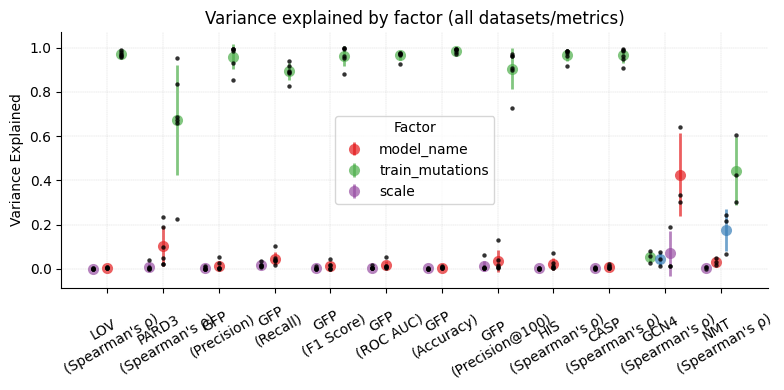

In [156]:

# Prepare feature-dataset labeling and data
df = df_var_all
combo = df[["var", "dataset"]].drop_duplicates()
feature_dataset_order = combo.apply(lambda row: f"{row['var']}\n{row['dataset']}", axis=1)
combo_y_label = df[["y_label", "dataset"]].drop_duplicates()
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1)

plot_df = []
for fd in feature_dataset_order:
    var, dataset = fd.split("\n", 1)
    comp_types = sorted(df.loc[(df['var'] == var) & (df['dataset'] == dataset), 'factor'].unique())
    for factor in comp_types:
        mask = (df["var"] == var) & (df["dataset"] == dataset) & (df["factor"] == factor)
        for val in df.loc[mask, "var_explained"]:
            plot_df.append({
                "feature_dataset": fd,
                "factor": factor,
                "var_explained": val
            })

plot_df = pd.DataFrame(plot_df)

# Compute mean and std for error bars
summary = plot_df.groupby(['feature_dataset', 'factor'])['var_explained'].agg(
    mean='mean', std='std'
).reset_index()

# Set colors: assign a fixed palette based on the full list of all possible factors, so color is always mapped in the same way
# Fix the order of all possible factors to keep color mapping stable
all_possible_factors = [
    "model_name", "budget", "train_mutations", "scale"
    # Add other factors you know of (even if not in all comparisons)
]
all_factors_present = [f for f in all_possible_factors if f in plot_df['factor'].unique()]
color_palette = sns.color_palette('Set1', n_colors=len(all_factors_present))
color_map = dict(zip(all_factors_present, color_palette))

# For each feature-dataset, get all factors and their stds; build dodge offsets based on std "ascending" order
fd_to_factors = {}
fd_to_n_factors = {}
fd_to_sorted_factors = {}
fd_to_dodge = {}

for fd in feature_dataset_order:
    # Get all present factors for this feature-dataset
    factors = [f for f in all_factors_present if not summary[(summary['feature_dataset'] == fd) & (summary['factor'] == f)].empty]
    # Get std for these factors (use 0 if none present, shouldn't happen)
    stds = [
        summary.loc[(summary['feature_dataset'] == fd) & (summary['factor'] == factor), 'std'].values[0] if
        not summary.loc[(summary['feature_dataset'] == fd) & (summary['factor'] == factor), 'std'].empty else 0.0
        for factor in factors
    ]
    # Order the factors for this subgroup by ascending std
    factors_sorted = [f for _, f in sorted(zip(stds, factors), key=lambda t: t[0])]
    fd_to_factors[fd] = factors_sorted
    fd_to_n_factors[fd] = len(factors_sorted)
    # Now assign dodge offsets: keep them centered/ordered by sorted factors for each category
    n_types = len(factors_sorted)
    width = 0.18 if n_types > 3 else 0.25
    fd_to_dodge[fd] = dict(
        zip(
            factors_sorted,
            [width * (i - (n_types - 1) / 2) for i in range(n_types)]
        )
    )
    fd_to_sorted_factors[fd] = factors_sorted

fig = plt.figure(figsize=(8, 4))

for i, fd in enumerate(feature_dataset_order):
    x_base = i
    factors_sorted = fd_to_sorted_factors[fd]
    dodge_pos = fd_to_dodge[fd]
    # Plot error bars for means +/- std (factors ordered by error bar size, lowest first)
    for factor in factors_sorted:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['factor'] == factor)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            x_base + dodge_pos[factor], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[factor],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            # Only add label for first group with this factor, so legend is not duplicated
            label=factor if (i == 0 and factor in all_factors_present) else "",
            zorder=0
        )

    # Overlay all scatter points for each (jittered/dodged, order matches errorbar order in group)
    for factor in factors_sorted:
        sub_points = plot_df[(plot_df['feature_dataset'] == fd) & (plot_df['factor'] == factor)]
        x_vals = [x_base + dodge_pos[factor]] * len(sub_points)
        plt.scatter(
            x_vals,
            sub_points['var_explained'],
            color="black",
            s=10,
            alpha=0.8,
            lw=0,
            zorder=2
        )

# Set x-ticks to match default 1.0 spacing
tick_locations = list(range(len(feature_dataset_order)))
plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(tick_locations, feature_dataset_order_y_label, rotation=30)
plt.ylabel("Variance Explained")
plt.xlabel("")
plt.title("Variance explained by factor (all datasets/metrics)")

from collections import OrderedDict

# sort legend as before
handles, labels = plt.gca().get_legend_handles_labels()
factor_label_to_handle = {lbl: hand for hand, lbl in zip(handles, labels)}
ordered_handles = []
ordered_labels = []
for factor in all_factors_present:
    if factor in factor_label_to_handle:
        ordered_handles.append(factor_label_to_handle[factor])
        ordered_labels.append(factor)
plt.legend(ordered_handles, ordered_labels, title="Factor")
plt.tight_layout()
plt.show()


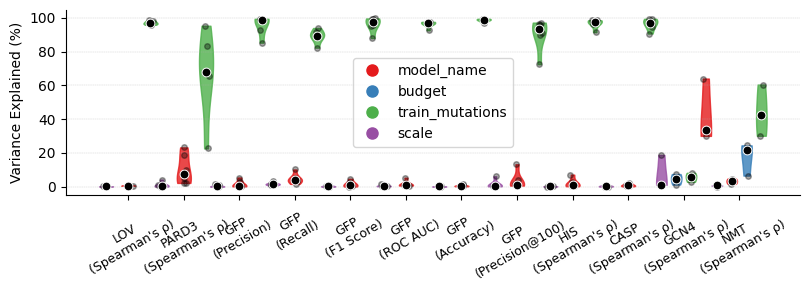

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume df_var_all is already loaded
df = df_var_all.copy()

# Multiply variance explained by 100 to get percent
df["var_explained"] = df["var_explained"] * 100

# Build unique var-dataset combos
combo = df[["var", "dataset"]].drop_duplicates().reset_index(drop=True)
combo["var_dataset"] = combo.apply(lambda r: f"{r['var']}\n{r['dataset']}", axis=1)
df = df.merge(combo, on=["var", "dataset"], how="left")

# Prepare x-label order and pretty y-labels
feature_dataset_order = combo["var_dataset"].tolist()
combo_y_label = combo.merge(df[["var", "dataset", "y_label"]].drop_duplicates(), on=["var", "dataset"], how="left")
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1).tolist()

# Define all known factor types; extend if needed
all_possible_factors = ["model_name", "budget", "train_mutations", "scale"]
factor_colors = sns.color_palette('Set1', n_colors=len(all_possible_factors))
factor_color_map = dict(zip(all_possible_factors, factor_colors))

# For each var_dataset combo, get sorted factor order by median var_explained (smallest-to-largest)
factor_orders_per_combo = {}
for vds in feature_dataset_order:
    _df = df[df["var_dataset"] == vds]
    factor_medians = {
        factor: _df.loc[_df["factor"] == factor, "var_explained"].median()
        for factor in _df["factor"].unique()
    }
    # Sort factors for this combo by median
    ordered_factors = sorted(factor_medians, key=lambda k: (factor_medians[k], k))
    factor_orders_per_combo[vds] = ordered_factors

# Set up canvas (match intended width)
fig, ax = plt.subplots(figsize=(8.2 , 3))

violin_width = 0.8 # total width for all violin groups at each var_dataset
scatter_alpha = 0.35
center_median_marker_size = 40

# X locations are integer-aligned by var_dataset
x_ticks = np.arange(len(feature_dataset_order))

for x_pos, vds in enumerate(feature_dataset_order):
    vdf = df[df["var_dataset"] == vds].copy()
    factors = factor_orders_per_combo[vds]
    n_factors = len(factors)
    # Violin midpoints for factors (centered about x integer position)
    offset_vec = np.linspace(-violin_width/2, violin_width/2, n_factors)

    for i, (factor, off) in enumerate(zip(factors, offset_vec)):
        sub = vdf[vdf["factor"] == factor]
        vals = sub["var_explained"].dropna().values
        _color = factor_color_map.get(factor, "gray")

        if len(vals) > 0:
            # Instead of seaborn's violinplot, use ax.violinplot.
            # ax.violinplot does not support unique y/positions per call, so we plot one at a time.
            parts = ax.violinplot(
                [vals], positions=[x_pos + off],
                widths=violin_width / n_factors * 0.95,
                showmeans=False, showmedians=False, showextrema=False
            )
            for pc in parts['bodies']:
                pc.set_facecolor(_color)
                pc.set_edgecolor(_color)
                pc.set_alpha(0.8)

            # Jitter actual points around the center of this violin
            jx = np.random.normal(loc=x_pos + off, scale=(violin_width / n_factors)*0.10, size=len(vals))
            ax.scatter(jx, vals, color="black", alpha=scatter_alpha, s=16, zorder=2)

            # Overlay median value in black, centered
            median = np.median(vals)
            ax.scatter([x_pos + off], [median], color="black", s=center_median_marker_size, zorder=4,
                       marker="o", edgecolor="white", linewidth=0.7)

# X ticks: one per var_dataset, pretty label
ax.set_xticks(x_ticks)
ax.set_xticklabels(feature_dataset_order_y_label, rotation=30, fontsize=9)

# Prepare ordered legend as in plot, without duplicates
seen = set()
legend_handles = []
legend_labels = []
for f in all_possible_factors:
    if any(f in factor_orders_per_combo[vds] for vds in feature_dataset_order) and f not in seen:
        seen.add(f)
        color = factor_color_map.get(f, "gray")
        h = plt.Line2D([0], [0], color=color, marker="o", linestyle="", markersize=8, label=f)
        legend_handles.append(h)
        legend_labels.append(f)
ax.legend(legend_handles, legend_labels)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Variance Explained (%)")
ax.set_xlabel("")
ax.grid(True, axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.tight_layout()
#plt.show()


save_dir = "./refined_figures"
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, "figure_models_comparision/variance_explained_by_factor.svg")
plt.savefig(fig_path, format='svg', bbox_inches="tight")
plt.show()





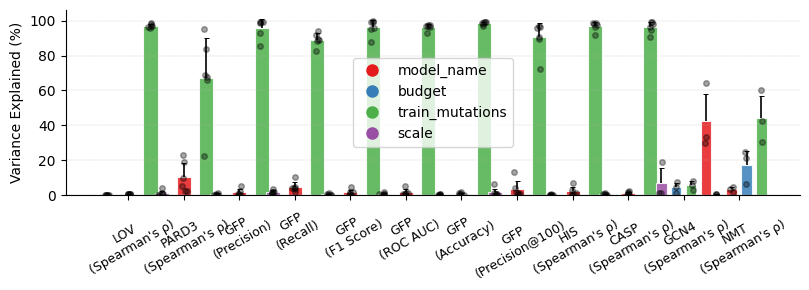

In [158]:

# Assume df_var_all is already loaded
df = df_var_all.copy()

# Multiply variance explained by 100 to get percent
df["var_explained"] = df["var_explained"] * 100

# Build unique var-dataset combos
combo = df[["var", "dataset"]].drop_duplicates().reset_index(drop=True)
combo["var_dataset"] = combo.apply(lambda r: f"{r['var']}\n{r['dataset']}", axis=1)
df = df.merge(combo, on=["var", "dataset"], how="left")

# Prepare x-label order and pretty y-labels
feature_dataset_order = combo["var_dataset"].tolist()
combo_y_label = combo.merge(df[["var", "dataset", "y_label"]].drop_duplicates(), on=["var", "dataset"], how="left")
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1).tolist()

# Define all known factor types
all_possible_factors = ["model_name", "budget", "train_mutations", "scale"]
factor_colors = sns.color_palette('Set1', n_colors=len(all_possible_factors))
factor_color_map = dict(zip(all_possible_factors, factor_colors))

# For each var_dataset combo, get sorted factor order by median var_explained (smallest-to-largest)
factor_orders_per_combo = {}
for vds in feature_dataset_order:
    _df = df[df["var_dataset"] == vds]
    factor_medians = {
        factor: _df.loc[_df["factor"] == factor, "var_explained"].median()
        for factor in _df["factor"].unique()
    }
    # Sort factors for this combo by median
    ordered_factors = sorted(factor_medians, key=lambda k: (factor_medians[k], k))
    factor_orders_per_combo[vds] = ordered_factors

# Set up canvas for barplot version
fig, ax = plt.subplots(figsize=(8.2, 3))

bar_width = 0.8  # total width for all bars at each var_dataset
scatter_alpha = 0.35
center_median_marker_size = 40
errorbar_linewidth = 1.2

# X locations are integer-aligned by var_dataset
x_ticks = np.arange(len(feature_dataset_order))

for x_pos, vds in enumerate(feature_dataset_order):
    vdf = df[df["var_dataset"] == vds].copy()
    factors = factor_orders_per_combo[vds]
    n_factors = len(factors)
    # Bar midpoints for factors (centered about x integer position)
    offset_vec = np.linspace(-bar_width/2, bar_width/2, n_factors)
    
    for i, (factor, off) in enumerate(zip(factors, offset_vec)):
        sub = vdf[vdf["factor"] == factor]
        vals = sub["var_explained"].dropna().values
        _color = factor_color_map.get(factor, "gray")

        if len(vals) > 0:
            mean = np.mean(vals)
            std = np.std(vals)
            bar_x = x_pos + off

            # Plot bar up to mean
            ax.bar(bar_x, mean, 
                   width=bar_width / n_factors * 0.95, 
                   color=_color, 
                   alpha=0.85,
                   zorder=1,
                   edgecolor="white",
                   linewidth=0.8)

            # Plot error bar: only +std as a thin black line, starting at mean
            # We plot a vertical black line from mean to mean+std if std > 0
            if std > 0:
                ax.vlines(bar_x, mean, mean + std, colors='black', linestyles='-', lw=errorbar_linewidth, zorder=3)
                # Optionally a small cap at the top
                ax.hlines(mean + std, bar_x - 0.045, bar_x + 0.045, colors='black', lw=0.7, zorder=3)

            # Jitter actual points around the center of this bar
            jx = np.random.normal(loc=bar_x, scale=(bar_width / n_factors)*0.10, size=len(vals))
            ax.scatter(jx, vals, color="black", alpha=scatter_alpha, s=16, zorder=4)

            # Overlay median value in black, centered
            # median = np.median(vals)
            # ax.scatter([bar_x], [median], color="black", s=center_median_marker_size, zorder=5,
            #            marker="o", edgecolor="white", linewidth=0.7)

# X ticks: one per var_dataset, pretty label
ax.set_xticks(x_ticks)
ax.set_xticklabels(feature_dataset_order_y_label, rotation=30, fontsize=9)

# Prepare ordered legend as in plot, without duplicates
seen = set()
legend_handles = []
legend_labels = []
for f in all_possible_factors:
    if any(f in factor_orders_per_combo[vds] for vds in feature_dataset_order) and f not in seen:
        seen.add(f)
        color = factor_color_map.get(f, "gray")
        h = plt.Line2D([0], [0], color=color, marker="o", linestyle="", markersize=8, label=f)
        legend_handles.append(h)
        legend_labels.append(f)
ax.legend(legend_handles, legend_labels)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Variance Explained (%)")
ax.set_xlabel("")
ax.grid(True, axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.tight_layout()
#plt.show()

save_dir = "./refined_figures"
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, "figure_models_comparision/variance_explained_by_factor_barplot.svg")
plt.savefig(fig_path, format='svg', bbox_inches="tight")
plt.show()




Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2

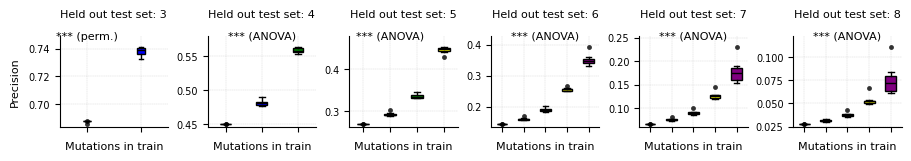

ANOVA SIZE 2 Groups, 8 points in group for recall[test_mutations] 3
Running permutation tests
### F = 120.873, p = 0.000 (permutation) | Kruskal-Wallis H = 11.944, p = nan
ANOVA SIZE 3 Groups, 8 points in group for recall[test_mutations] 4
### F = 49.227, p = 0.000 (ANOVA) | Kruskal-Wallis H = 18.454, p = 0.000
ANOVA SIZE 4 Groups, 8 points in group for recall[test_mutations] 5
### F = 101.646, p = 0.000 (ANOVA) | Kruskal-Wallis H = 26.599, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for recall[test_mutations] 6
### F = 139.111, p = 0.000 (ANOVA) | Kruskal-Wallis H = 35.366, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for recall[test_mutations] 7
### F = 67.641, p = 0.000 (ANOVA) | Kruskal-Wallis H = 36.345, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for recall[test_mutations] 8
### F = 71.805, p = 0.000 (ANOVA) | Kruskal-Wallis H = 36.354, p = 0.000


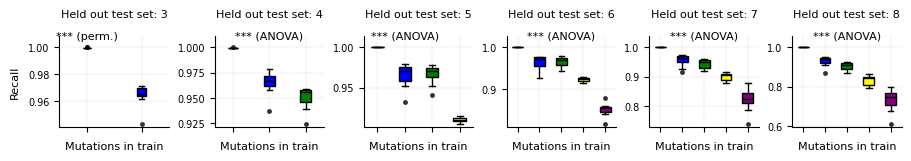

ANOVA SIZE 2 Groups, 8 points in group for f1[test_mutations] 3
Running permutation tests
### F = 348.799, p = 0.000 (permutation) | Kruskal-Wallis H = 11.907, p = nan
ANOVA SIZE 3 Groups, 8 points in group for f1[test_mutations] 4
### F = 4273.000, p = 0.000 (ANOVA) | Kruskal-Wallis H = 20.796, p = 0.000
ANOVA SIZE 4 Groups, 8 points in group for f1[test_mutations] 5
### F = 2303.910, p = 0.000 (ANOVA) | Kruskal-Wallis H = 29.279, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for f1[test_mutations] 6
### F = 1065.132, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.587, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for f1[test_mutations] 7
### F = 174.879, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.587, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for f1[test_mutations] 8
### F = 64.831, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.254, p = 0.000


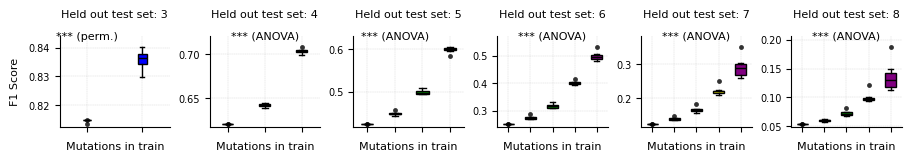

ANOVA SIZE 2 Groups, 8 points in group for roc[test_mutations] 3
Running permutation tests
### F = 179.604, p = 0.000 (permutation) | Kruskal-Wallis H = 11.294, p = nan
ANOVA SIZE 3 Groups, 8 points in group for roc[test_mutations] 4
### F = 342.166, p = 0.000 (ANOVA) | Kruskal-Wallis H = 20.480, p = 0.000
ANOVA SIZE 4 Groups, 8 points in group for roc[test_mutations] 5
### F = 392.033, p = 0.000 (ANOVA) | Kruskal-Wallis H = 29.091, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for roc[test_mutations] 6
### F = 373.699, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.463, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for roc[test_mutations] 7
### F = 305.782, p = 0.000 (ANOVA) | Kruskal-Wallis H = 35.707, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for roc[test_mutations] 8
### F = 239.170, p = 0.000 (ANOVA) | Kruskal-Wallis H = 35.738, p = 0.000


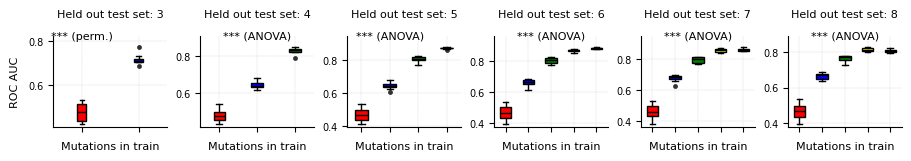

ANOVA SIZE 2 Groups, 8 points in group for accuracy[test_mutations] 3
Running permutation tests
### F = 1171.478, p = 0.000 (permutation) | Kruskal-Wallis H = 11.925, p = nan
ANOVA SIZE 3 Groups, 8 points in group for accuracy[test_mutations] 4
### F = 2317.301, p = 0.000 (ANOVA) | Kruskal-Wallis H = 20.796, p = 0.000
ANOVA SIZE 4 Groups, 8 points in group for accuracy[test_mutations] 5
### F = 1379.423, p = 0.000 (ANOVA) | Kruskal-Wallis H = 29.279, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for accuracy[test_mutations] 6
### F = 1069.167, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.587, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for accuracy[test_mutations] 7
### F = 434.516, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.587, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for accuracy[test_mutations] 8
### F = 285.449, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.254, p = 0.000


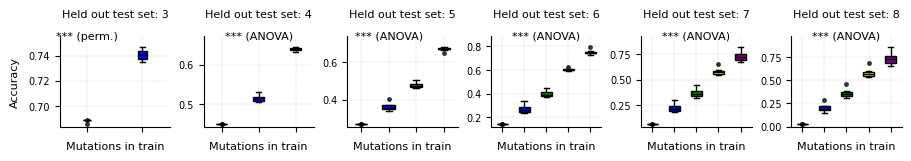

ANOVA SIZE 2 Groups, 8 points in group for top_100_pct[test_mutations] 3
Running permutation tests
### F = 37.140, p = 0.000 (permutation) | Kruskal-Wallis H = 11.311, p = nan
ANOVA SIZE 3 Groups, 8 points in group for top_100_pct[test_mutations] 4
### F = 92.331, p = 0.000 (ANOVA) | Kruskal-Wallis H = 19.096, p = 0.000
ANOVA SIZE 4 Groups, 8 points in group for top_100_pct[test_mutations] 5
### F = 92.440, p = 0.000 (ANOVA) | Kruskal-Wallis H = 27.183, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for top_100_pct[test_mutations] 6
### F = 215.486, p = 0.000 (ANOVA) | Kruskal-Wallis H = 35.548, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for top_100_pct[test_mutations] 7
### F = 223.042, p = 0.000 (ANOVA) | Kruskal-Wallis H = 33.585, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for top_100_pct[test_mutations] 8
### F = 310.529, p = 0.000 (ANOVA) | Kruskal-Wallis H = 35.382, p = 0.000


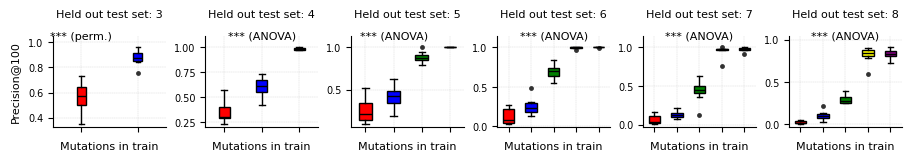


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV 

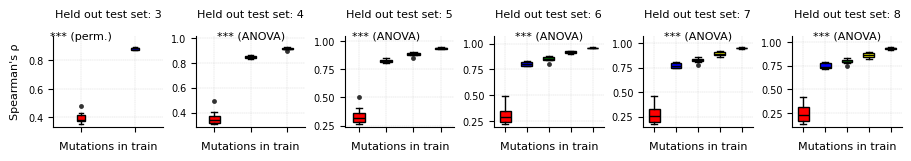


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.

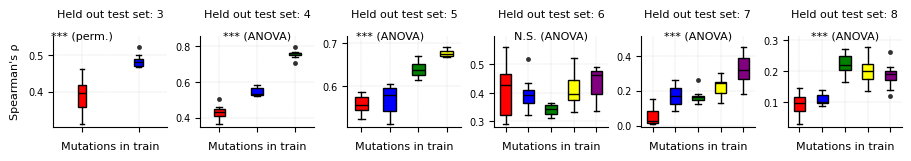


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/his/his_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evaluation

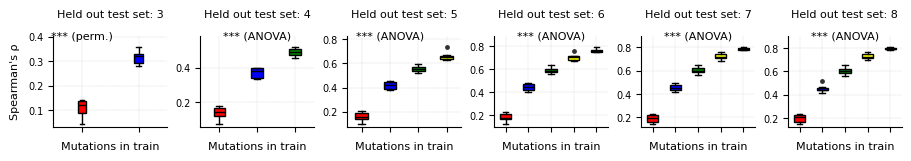


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/casp/casp_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_ev

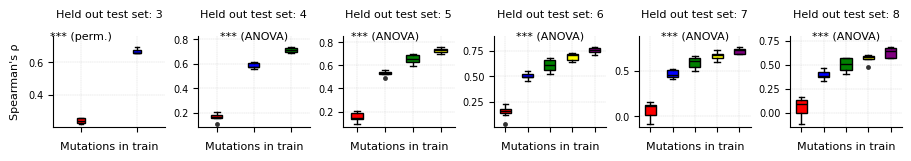

In [160]:

train_muts_anova_agg = {
    "feature": [],
    "comparison_type": [],
    "mutations": [],
    "dataset": [],
    "test_type": [],
    "F_value": [],
    "P_value": [],
    "Kruskal_H": [],
    "Kruskal_P": []
}

by_subsample_datasets = ["gfp", "lov", "pard3", "his", "casp"]

features_per_dataset = {
    "gfp": ["precision", "recall", "f1", "roc", "accuracy", "top_100_pct"],
    "lov": ["correlation"],
    "pard3": ["correlation"],
    "his": ["correlation"],
    "casp": ["correlation"]
}

all_dfs = []

fig_path = "./refined_figures/supp_figure_var_analysis/"
os.makedirs(fig_path, exist_ok=True)
for ds in by_subsample_datasets:
    embedding_base_dir = "%s/data/%s/%s_regression_optimal" % (base_path, ds, ds)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)
    all_dfs.append((ds, df_all, ohe_df_all))
    for feature in features_per_dataset[ds]:
        train_muts_anova_agg = run_mut_comparision_anova_and_plot(
            df=df_all,
            dataset_name=ds,
            feature_name=feature,
            mutations=[3,4,5,6,7,8],
            mutation_factor_colname="test_mutations",
            results=train_muts_anova_agg,
            do_plot=True,
            verbose=True,
            train=False,
            comp_factor="train_mutations",
            color_map={1: "red", 2: "blue", 3: "green", 4: "yellow", 5: "purple"},
            fig_path=os.path.join(fig_path, f"{ds}_{feature}_by_model.svg")
        )

/tmp/ipykernel_694596/3186546324.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_694596/3186546324.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_694596/3186546324.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will def

ANOVA SIZE 4 Groups, 8 points in group for cor_llm[set] 9
### F = 30.893, p = 0.000 (ANOVA) | Kruskal-Wallis H = 19.168, p = 0.000
ANOVA SIZE 5 Groups, 8 points in group for cor_llm[set] 10
### F = 139.419, p = 0.000 (ANOVA) | Kruskal-Wallis H = 30.060, p = 0.000
ANOVA SIZE 6 Groups, 8 points in group for cor_llm[set] 11
### F = 33.678, p = 0.000 (ANOVA) | Kruskal-Wallis H = 37.314, p = 0.000


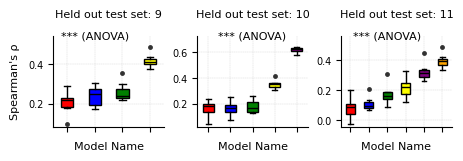

/tmp/ipykernel_694596/3186546324.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_694596/3186546324.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_694596/3186546324.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Eithe

ANOVA SIZE 3 Groups, 8 points in group for cor_llm[set] 6
### F = 0.318, p = 0.731 (ANOVA) | Kruskal-Wallis H = 0.560, p = 0.756
ANOVA SIZE 4 Groups, 8 points in group for cor_llm[set] 7
### F = 1.242, p = 0.313 (ANOVA) | Kruskal-Wallis H = 2.725, p = 0.436
ANOVA SIZE 5 Groups, 8 points in group for cor_llm[set] 8
### F = 1.726, p = 0.166 (ANOVA) | Kruskal-Wallis H = 7.138, p = 0.129


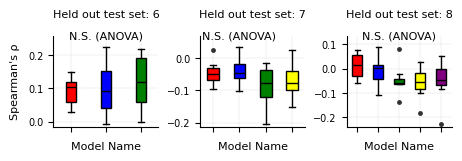

In [162]:

budgeted_sets = [
    ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
    ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
]


nmt_color_map = {5: "red", 6: "blue", 7: "green", 8: "yellow", 9: "purple", 10: "orange"}
gcn_color_map = {3: "red", 4: "blue", 5: "green", 6: "yellow", 7: "purple"}
for name, sets, train, test, group_func in budgeted_sets:
    all_dfs = []
    for set_name, set_df in sets.items():
        grouped_df = group_func(set_df)
        grouped_df["set"] = int(set_name.split("_")[-1])
        all_dfs.append(grouped_df)
    all_dfs = pd.concat(all_dfs)
    all_dfs = all_dfs[all_dfs["model_name"] != "one_hot"]
    
    train_muts_anova_agg = run_mut_comparision_anova_and_plot(
        df=all_dfs,
        dataset_name=name,
        feature_name="cor_llm",
        mutations=test,
        mutation_factor_colname="set",
        results=train_muts_anova_agg,
        do_plot=True,
        verbose=True,
        train=False,
        color_map=nmt_color_map if name == "nmt" else gcn_color_map,
        comp_factor="max_muts_in_train",
        fig_path=os.path.join(fig_path, f"{name}_test_mutations.svg")
    )



In [166]:
train_final_pvalue_df = pd.DataFrame(train_muts_anova_agg)

In [167]:
train_final_pvalue_df

,feature,comparison_type,mutations,dataset,test_type,F_value,P_value,Kruskal_H,Kruskal_P
0,precision,test,3,gfp,permutation,2046.642309,0.000000e+00,11.906977,NaN
1,precision,test,4,gfp,ANOVA,2253.290287,3.138395e-25,20.796468,3.048627e-05
2,precision,test,5,gfp,ANOVA,1834.700528,3.130433e-32,29.278731,1.956857e-06
3,precision,test,6,gfp,ANOVA,643.512793,3.121553e-32,37.586824,1.363470e-07
4,precision,test,7,gfp,ANOVA,119.202483,7.078096e-20,37.586824,1.363470e-07
...,...,...,...,...,...,...,...,...,...
67,cor_llm,test,10,nmt,ANOVA,139.418821,5.484078e-21,30.060366,4.757874e-06
68,cor_llm,test,11,nmt,ANOVA,33.677587,1.159807e-13,37.313776,5.181640e-07
69,cor_llm,test,6,gcn,ANOVA,0.317683,7.312703e-01,0.560000,7.557837e-01
70,cor_llm,test,7,gcn,ANOVA,1.241524,3.133530e-01,2.724720,4.360427e-01


/tmp/ipykernel_694596/2060847704.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


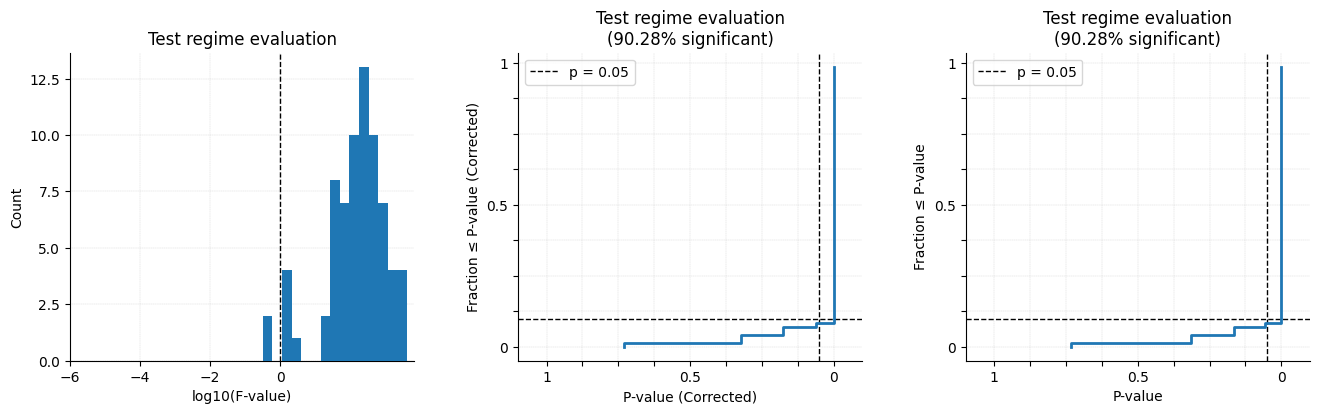

In [168]:
# Perform FDR correction on the P_value column, add as new column 'FDR_corrected'
train_final_pvalue_df["FDR_corrected"] = fdr_bh(train_final_pvalue_df["P_value"].values)

# Prepare all three views and their titles
all_dfs = [
    train_final_pvalue_df[train_final_pvalue_df["comparison_type"] == "test"],
    train_final_pvalue_df[train_final_pvalue_df["comparison_type"] == "test"],
    train_final_pvalue_df[train_final_pvalue_df["comparison_type"] == "test"]
]

all_titles = [
    "Test regime evaluation",  # For f-value hist
    "Test regime evaluation",  # For FDR-corrected p-value
    "Test regime evaluation"   # For raw p-value
]

# For f-value histogram
xlabelticks = [
    [-6, -4, -2, 0],    # update if needed for all three
    [-2, -1,  0, 1],
    [-6, -4, -2, 0]
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.3}, sharey=False)

# Plot 1: Histogram of log10(F-value)
fvalues = np.log10(all_dfs[0]["F_value"].dropna())
axes[0].hist(fvalues, bins=15, zorder=3)
axes[0].grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
spines = axes[0].spines
spines['right'].set_visible(False)
spines['top'].set_visible(False)
axes[0].set_xlabel("log10(F-value)")
axes[0].axvline(0, lw="1", color="k", linestyle="dashed", zorder=3)
axes[0].set_title(all_titles[0])
axes[0].set_xticks(xlabelticks[0])
axes[0].yaxis.set_major_locator(MultipleLocator(2.5))
axes[0].set_ylabel("Count")

# Plot 2: FDR-corrected P-value cumulative distribution
df_fdr = all_dfs[1]
pvalues = df_fdr["FDR_corrected"].dropna().sort_values()
cumulative = 1 - np.arange(1, len(pvalues) + 1) / len(pvalues)
portion = 1 - sum(pvalues < 0.05) / len(pvalues)
axes[1].set_xlabel("P-value (Corrected)")
axes[1].set_title(f"{all_titles[1]}\n({(1 - portion) * 100:.2f}% significant)")
axes[1].set_xticks([1, 0.5, 0])
axes[1].set_xticklabels(['1', '0.5', '0'])
axes[1].set_yticks([1, 0.5, 0])
axes[1].set_yticklabels(['1', '0.5', '0'])
axes[1].axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
if len(pvalues) > 0:
    axes[1].axhline(portion, color='k', linestyle='dashed', lw=1)
axes[1].set_xlim(1.1, -0.1)
axes[1].step(pvalues[::-1], cumulative[::-1], where="post", lw=2)
axes[1].xaxis.set_major_locator(MultipleLocator(0.125))    
axes[1].yaxis.set_major_locator(MultipleLocator(0.125))
axes[1].grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
spines = axes[1].spines
spines['right'].set_visible(False)
spines['top'].set_visible(False)
axes[1].set_ylabel("Fraction ≤ P-value (Corrected)")
axes[1].legend()

# Plot 3: Raw P-value cumulative distribution
df_raw = all_dfs[2]
pvalues = df_raw["P_value"].dropna().sort_values()
cumulative = 1 - np.arange(1, len(pvalues) + 1) / len(pvalues)
portion = 1 - sum(pvalues < 0.05) / len(pvalues)
axes[2].set_xlabel("P-value")
axes[2].set_title(f"{all_titles[2]}\n({(1 - portion) * 100:.2f}% significant)")
axes[2].set_xticks([1, 0.5, 0])
axes[2].set_xticklabels(['1', '0.5', '0'])
axes[2].set_yticks([1, 0.5, 0])
axes[2].set_yticklabels(['1', '0.5', '0'])
axes[2].axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
if len(pvalues) > 0:
    axes[2].axhline(portion, color='k', linestyle='dashed', lw=1)
axes[2].set_xlim(1.1, -0.1)
axes[2].step(pvalues[::-1], cumulative[::-1], where="post", lw=2)
axes[2].xaxis.set_major_locator(MultipleLocator(0.125))    
axes[2].yaxis.set_major_locator(MultipleLocator(0.125))
axes[2].grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
spines = axes[2].spines
spines['right'].set_visible(False)
spines['top'].set_visible(False)
axes[2].set_ylabel("Fraction ≤ P-value")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "f_value_and_pvalue_distributions_combined.svg"), format="svg")
plt.show()


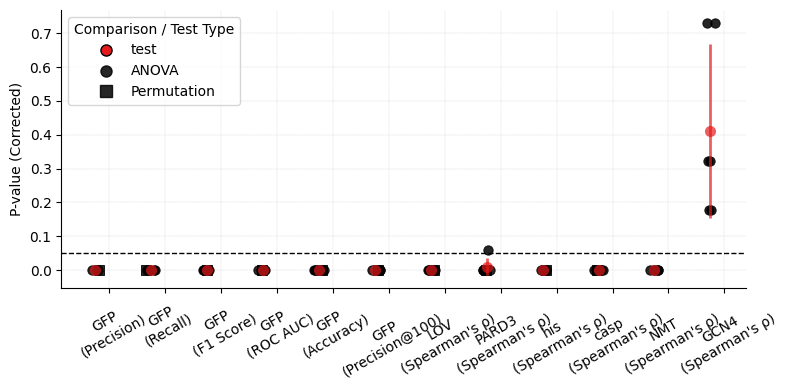

In [169]:
# Consistent naming as in file_context_0
train_final_pvalue_df = train_final_pvalue_df.copy()
train_final_pvalue_df.loc[train_final_pvalue_df["dataset"] == "gfp", "dataset"] = "GFP"
train_final_pvalue_df.loc[train_final_pvalue_df["dataset"] == "pard3", "dataset"] = "PARD3"
train_final_pvalue_df.loc[train_final_pvalue_df["dataset"] == "nmt", "dataset"] = "NMT"
train_final_pvalue_df.loc[train_final_pvalue_df["dataset"] == "gcn", "dataset"] = "GCN4"
train_final_pvalue_df.loc[train_final_pvalue_df["dataset"] == "lov", "dataset"] = "LOV"

plt.figure(figsize=(8, 4))

# Prepare label mapping for pretty axis labels as in file_context_0
combo = train_final_pvalue_df[["feature", "dataset"]].drop_duplicates()

try:
    display_label_dict = ylabel_dict
except NameError:
    display_label_dict = {}

feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

def get_ylabel(feat):
    return display_label_dict.get(feat, feat.replace("_", " ").title())

feature_dataset_order_y_label = combo.apply(
    lambda row: f"{row['dataset']}\n({get_ylabel(row['feature'])})", axis=1
)

plot_order = feature_dataset_order
plot_xticks = feature_dataset_order_y_label

plot_df = []
for fd, pretty_label in zip(plot_order, plot_xticks):
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["test"]:
        if comp_type == "all":
            mask = (train_final_pvalue_df["feature"] == feature) & (train_final_pvalue_df["dataset"] == dataset)
        else:
            mask = (
                (train_final_pvalue_df["feature"] == feature)
                & (train_final_pvalue_df["dataset"] == dataset)
                & (train_final_pvalue_df["comparison_type"] == comp_type)
            )
        idxs = train_final_pvalue_df.loc[mask].index
        for idx in idxs:
            val = train_final_pvalue_df.at[idx, "FDR_corrected"]
            test_type = train_final_pvalue_df.at[idx, "test_type"] if "test_type" in train_final_pvalue_df.columns else None
            plot_df.append({
                "feature_dataset": fd,
                "feature_dataset_y": pretty_label,
                "comparison_type": comp_type,
                "P_value": val,
                "test_type": test_type.lower() if isinstance(test_type, str) else None
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["test"])]
plot_df = plot_df[plot_df["feature_dataset"].isin(plot_order)]

# Compute summary statistics per feature_dataset and comparison_type
summary = plot_df.groupby(['feature_dataset', 'comparison_type'])['P_value'].agg(
    mean='mean', std='std'
).reset_index()

comparison_types = ["test"]
colors = sns.color_palette('Set1', n_colors=3)
color_map = dict(zip(comparison_types, colors))

width = 0.25
dodge_pos = dict(zip(comparison_types, [-width, 0, width]))

# Plot mean/std (errorbar) per type in colored dots, overlaid with scatter of all points, style by test_type
for i, (fd, pretty_label) in enumerate(zip(plot_order, plot_xticks)):
    for comp_type in comparison_types:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['comparison_type'] == comp_type)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            i + dodge_pos[comp_type], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[comp_type],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            label=comp_type if (i == 0) else "",
            zorder=4
        )

# Marker dict: 'anova' -> 'o' (circle), 'permutation' -> 's' (square)
# Both solid black
marker_dict = {"anova": "o", "permutation": "s", None: "o"}
label_dict = {"anova": "ANOVA", "permutation": "Permutation"}

scatter_legend_handles = {}
# Draw all points individually, grouping by test_type for style
for i, fd in enumerate(plot_order):
    for ci, comp_type in enumerate(comparison_types):
        pts = plot_df[
            (plot_df["feature_dataset"] == fd) &
            (plot_df["comparison_type"] == comp_type)
        ]
        # group by test_type so we can draw with a consistent style
        for tt in pts["test_type"].unique():
            pts_tt = pts[pts["test_type"] == tt]
            if pts_tt.empty:
                continue
            xpos = i + dodge_pos[comp_type] + np.random.uniform(-0.09, 0.09, len(pts_tt))
            y = pts_tt["P_value"].values
            marker = marker_dict.get(tt, "o")
            # Solid black marker for both styles. edgecolors to 'black' as well.
            hdl = plt.scatter(
                xpos, y,
                s=45,
                marker=marker,
                color="black",
                alpha=0.85,
                linewidth=0.7,
                edgecolors='black',
                zorder=3,
                label=None
            )
            # For legend: only add 1st handle per test_type
            if tt not in scatter_legend_handles:
                scatter_legend_handles[tt] = hdl

plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(
    range(len(plot_order)),
    plot_xticks,
    rotation=30
)
plt.ylabel("P-value (Corrected)")
plt.xlabel("")
plt.axhline(0.05, color='k', linestyle='dashed', lw=1)

# Compose legend for test_type
from matplotlib.lines import Line2D

custom_legend = []
ordered_types = ['anova', 'permutation']
for tt in ordered_types:
    if tt in scatter_legend_handles:
        custom_legend.append(
            Line2D(
                [0], [0],
                marker=marker_dict[tt],
                color='black',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=8,
                alpha=0.85,
                linestyle='None',
                label=label_dict[tt]
            )
        )

# Add also the comparison type legend by overlaying points of the main colors
comp_type_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[comp_type],
        markeredgecolor="black",
        markersize=8,
        linestyle='None',
        label=comp_type
    )
    for comp_type in comparison_types
]

plt.legend(
    handles=comp_type_legend + custom_legend,
    title="Comparison / Test Type",
    loc='best'
)
plt.tight_layout()
# Save the figure to the specified figure path as SVG with font type saved as 'font'
#plt.savefig(os.path.join(fig_path, "pvalue_dist_corrected_fdr_new_train_as_factor.svg"), format="svg")
plt.show()


In [139]:
train_final_pvalue_df

,feature,comparison_type,mutations,dataset,test_type,F_value,P_value,Kruskal_H,Kruskal_P,FDR_corrected
0,precision,test,3,GFP,permutation,2046.642309,0.000000e+00,11.906977,NaN,0.000000e+00
1,precision,test,4,GFP,ANOVA,2253.290287,3.138395e-25,20.796468,3.048627e-05,6.974211e-25
2,precision,test,5,GFP,ANOVA,1834.700528,3.130433e-32,29.278731,1.956857e-06,1.252173e-31
3,precision,test,6,GFP,ANOVA,643.512793,3.121553e-32,37.586824,1.363470e-07,1.252173e-31
4,precision,test,7,GFP,ANOVA,119.202483,7.078096e-20,37.586824,1.363470e-07,1.088938e-19
5,precision,test,8,GFP,ANOVA,51.086878,3.896720e-14,37.254471,1.596443e-07,4.771494e-14
6,recall,test,3,GFP,permutation,120.873149,0.000000e+00,11.944012,NaN,0.000000e+00
7,recall,test,4,GFP,ANOVA,49.226807,1.182252e-08,18.454323,9.833197e-05,1.313613e-08
8,recall,test,5,GFP,ANOVA,101.645763,3.683562e-15,26.599050,7.144231e-06,4.804646e-15
9,recall,test,6,GFP,ANOVA,139.110840,5.686749e-21,35.365876,3.906995e-07,8.979078e-21


In [140]:
test_type

'ANOVA'

In [141]:
plot_df

,feature_dataset,feature_dataset_y,comparison_type,P_value,test_type
0,precision\nGFP,GFP\n(Precision),test,0.000000e+00,permutation
1,precision\nGFP,GFP\n(Precision),test,6.974211e-25,anova
2,precision\nGFP,GFP\n(Precision),test,1.252173e-31,anova
3,precision\nGFP,GFP\n(Precision),test,1.252173e-31,anova
4,precision\nGFP,GFP\n(Precision),test,1.088938e-19,anova
5,precision\nGFP,GFP\n(Precision),test,4.771494e-14,anova
6,recall\nGFP,GFP\n(Recall),test,0.000000e+00,permutation
7,recall\nGFP,GFP\n(Recall),test,1.313613e-08,anova
8,recall\nGFP,GFP\n(Recall),test,4.804646e-15,anova
9,recall\nGFP,GFP\n(Recall),test,8.979078e-21,anova


In [142]:
train_final_pvalue_df.loc[mask]

,feature,comparison_type,mutations,dataset,test_type,F_value,P_value,Kruskal_H,Kruskal_P,FDR_corrected
57,cor_llm,test,6,GCN4,ANOVA,0.317683,0.731270,0.560000,0.755784,0.731270
58,cor_llm,test,7,GCN4,ANOVA,1.241524,0.313353,2.724720,0.436043,0.318664
59,cor_llm,test,8,GCN4,ANOVA,1.726356,0.166232,7.137739,0.128786,0.171964


In [143]:
plot_df

,feature_dataset,feature_dataset_y,comparison_type,P_value,test_type
0,precision\nGFP,GFP\n(Precision),test,0.000000e+00,permutation
1,precision\nGFP,GFP\n(Precision),test,6.974211e-25,anova
2,precision\nGFP,GFP\n(Precision),test,1.252173e-31,anova
3,precision\nGFP,GFP\n(Precision),test,1.252173e-31,anova
4,precision\nGFP,GFP\n(Precision),test,1.088938e-19,anova
5,precision\nGFP,GFP\n(Precision),test,4.771494e-14,anova
6,recall\nGFP,GFP\n(Recall),test,0.000000e+00,permutation
7,recall\nGFP,GFP\n(Recall),test,1.313613e-08,anova
8,recall\nGFP,GFP\n(Recall),test,4.804646e-15,anova
9,recall\nGFP,GFP\n(Recall),test,8.979078e-21,anova


In [144]:
combo

,feature,dataset
0,precision,GFP
6,recall,GFP
12,f1,GFP
18,roc,GFP
24,accuracy,GFP
30,top_100_pct,GFP
36,correlation,LOV
42,correlation,PARD3
48,correlation,his
54,cor_llm,NMT


In [145]:
train_final_pvalue_df

,feature,comparison_type,mutations,dataset,test_type,F_value,P_value,Kruskal_H,Kruskal_P,FDR_corrected
0,precision,test,3,GFP,permutation,2046.642309,0.000000e+00,11.906977,NaN,0.000000e+00
1,precision,test,4,GFP,ANOVA,2253.290287,3.138395e-25,20.796468,3.048627e-05,6.974211e-25
2,precision,test,5,GFP,ANOVA,1834.700528,3.130433e-32,29.278731,1.956857e-06,1.252173e-31
3,precision,test,6,GFP,ANOVA,643.512793,3.121553e-32,37.586824,1.363470e-07,1.252173e-31
4,precision,test,7,GFP,ANOVA,119.202483,7.078096e-20,37.586824,1.363470e-07,1.088938e-19
5,precision,test,8,GFP,ANOVA,51.086878,3.896720e-14,37.254471,1.596443e-07,4.771494e-14
6,recall,test,3,GFP,permutation,120.873149,0.000000e+00,11.944012,NaN,0.000000e+00
7,recall,test,4,GFP,ANOVA,49.226807,1.182252e-08,18.454323,9.833197e-05,1.313613e-08
8,recall,test,5,GFP,ANOVA,101.645763,3.683562e-15,26.599050,7.144231e-06,4.804646e-15
9,recall,test,6,GFP,ANOVA,139.110840,5.686749e-21,35.365876,3.906995e-07,8.979078e-21


In [146]:
train_muts_anova_agg

{'feature': ['precision',
  'precision',
  'precision',
  'precision',
  'precision',
  'precision',
  'recall',
  'recall',
  'recall',
  'recall',
  'recall',
  'recall',
  'f1',
  'f1',
  'f1',
  'f1',
  'f1',
  'f1',
  'roc',
  'roc',
  'roc',
  'roc',
  'roc',
  'roc',
  'accuracy',
  'accuracy',
  'accuracy',
  'accuracy',
  'accuracy',
  'accuracy',
  'top_100_pct',
  'top_100_pct',
  'top_100_pct',
  'top_100_pct',
  'top_100_pct',
  'top_100_pct',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'correlation',
  'cor_llm',
  'cor_llm',
  'cor_llm',
  'cor_llm',
  'cor_llm',
  'cor_llm'],
 'comparison_type': ['test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'test',
  'te

In [147]:
fvalues

0     3.311042
1     3.352817
2     3.263565
3     2.808557
4     2.076285
5     1.708309
6     2.082330
7     1.692202
8     2.007089
9     2.143361
10    1.830207
11    1.856156
12    2.542576
13    3.630733
14    3.362466
15    3.027404
16    2.242737
17    1.811786
18    2.254315
19    2.534237
20    2.593322
21    2.572522
22    2.485411
23    2.378706
24    3.068734
25    3.364982
26    3.139698
27    3.029046
28    2.638005
29    2.455528
30    1.569843
31    1.965347
32    1.965858
33    2.333420
34    2.348388
35    2.492102
36    3.021723
37    2.718760
38    2.523031
39    2.427417
40    2.361643
41    2.316545
42    1.430917
43    2.340282
44    1.676429
45    0.408438
46    1.285040
47    1.259118
48    2.183409
49    2.427241
50    2.546600
51    2.723154
52    2.809535
53    2.764199
54    1.489865
55    2.144321
56    1.527341
57   -0.498006
58    0.093955
59    0.237130
Name: F_value, dtype: float64